# Data Extraction Pipeline for Bachelor's Thesis Project - Machine and Deep Learning Approaches to Heart Rate Estimation from Speech with Interpretability and Fairness Analysis

## Dataset Loading

In [12]:
# Display settings 

import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.set_printoptions(suppress=True, precision=4)

### Creating tesdhe_metadata.csv

In [2]:
import os
import re
import pandas as pd

# --------- DIRECTORY ---------
data_dir = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE/Speech Signals"
save_dir = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data"
output_csv = os.path.join(save_dir, "tesdhe_metadata.csv")

# --------- FILENAME PATTERN ---------
# Example: En026F220722R130.ogg
PATTERN = re.compile(
    r'^(En|Ta)'           # language
    r'(\d{3})'            # speaker number
    r'([MF])'             # gender
    r'(\d{4})'            # age: YYMM
    r'(\d{2})'            # question number
    r'([ARV])'            # response type
    r'(\d{2,4})'          # bpm
    r'\.(ogg|wav|mp3)$',  # extension
    re.IGNORECASE
)

LANG_MAP = {"En": "English", "Ta": "Tamil"}
RESP_MAP = {"A": "Answering", "R": "Reading", "V": "AfterVideo"}

def parse_filename(fname: str, data_dir: str):

    base = os.path.basename(fname)
    m = PATTERN.match(base)

    if not m:
        return None

    lang, spk, gender, age4, q, resp, bpm, ext = m.groups()

    # Normalize case
    lang = lang[0].upper() + lang[1:].lower()   # En / Ta
    gender = gender.upper()                     # M / F
    resp = resp.upper()                         # A / R / V
    ext = ext.lower()                           # ogg / wav / mp3

    age_years = int(age4[:2])                   # e.g. 22
    age_months = int(age4[2:])                  # e.g. 07

    return {
        "file_name": base,
        "language_code": lang,
        "language": LANG_MAP.get(lang, lang),
        "speaker_id": int(spk),
        "gender": gender,
        "age_raw": age4,
        "age_years": age_years,
        "age_months": age_months,
        "question_number": int(q),
        "response_type_code": resp,
        "response_type": RESP_MAP.get(resp, resp),
        "bpm": int(bpm),
        "extension": ext,
    }

def build_metadata_csv(data_dir: str, output_csv: str):

    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    rows = []
    skipped = []

    for fn in os.listdir(data_dir):

        if not fn.lower().endswith((".ogg", ".wav", ".mp3")):
            continue

        parsed = parse_filename(fn, data_dir)

        if parsed is None:
            skipped.append(fn)
            continue

        rows.append(parsed)

    if not rows:
        print("No files were parsed successfully.")
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values(
        ["language_code", "speaker_id", "question_number"]
    )

    df.to_csv(output_csv, index=False)

    print(f"Saved CSV to: {output_csv}")
    print(f"Parsed files: {len(df)}")
    print(f"Skipped files: {len(skipped)}")

    if skipped:
        print("\nExamples of skipped files:")
        for s in skipped:
            print(" -", s)

    return df


# --------- RUN & CHECK FOR EXISTENCE ---------
from pathlib import Path
import pandas as pd

metadata_path = Path(output_csv)

if metadata_path.exists():
    metadata = pd.read_csv(metadata_path)
    print("tesdhe_metadata.csv already exists \n")
else:
    metadata = build_metadata_csv(data_dir, output_csv)
    metadata = pd.read_csv(metadata_path)
    print("tesdhe_metadata.csv created \n")

print(metadata.head())

Saved CSV to: /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv
Parsed files: 10034
Skipped files: 14

Examples of skipped files:
 - En071M270604A079(1).ogg
 - En041F221016A082(1).ogg
 - En071M270609A079(1).ogg
 - En071M270606A079(1).ogg
 - En041F221020R085(1).ogg
 - En071M270607A080(1).ogg
 - En041F221015A086(1).ogg
 - En041F221018R084(1).ogg
 - En041F221017R082(1).ogg
 - En071M270608A073(1).ogg
 - En071M270605A080(1).ogg
 - En041F221019R083(1).ogg
 - En041F221013A085(1).ogg
 - En041F221014A083(1).ogg
tesdhe_metadata.csv created 

              file_name language_code language  speaker_id gender  age_raw  \
0  En001M240401A083.ogg            En  English           1      M     2404   
1  En001M240402A079.ogg            En  English           1      M     2404   
2  En001M240403A076.ogg            En  English           1      M     2404   
3  En001M240404A076.ogg            En  English           1      M     2404   
4  En001M240405A071.ogg            En  English

## Skipped files investigation

To determine whether they are duplicates or the saving process was faulty.


In [3]:
import os
import re
import pandas as pd

data_dir = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE/Speech Signals"

# Same pattern used in the main parser
VALID_PATTERN = re.compile(
    r'^(En|Ta)(\d{3})([MF])(\d{4})(\d{2})([ARV])(\d{2,4})\.(ogg|wav|mp3)$',
    re.IGNORECASE
)

# Detect duplicate suffix like " (1)" or "(1)"
COPY_PATTERN = re.compile(r'^(.*?)(?:\s)?\((\d+)\)(\.[^.]+)$')



all_files = os.listdir(data_dir)
file_set = set(all_files)

investigation = []

for f in all_files:

    if not f.lower().endswith((".ogg",".wav",".mp3")):
        continue

    # Skip files that were valid
    if VALID_PATTERN.match(f):
        continue

    duplicate_match = COPY_PATTERN.match(f)

    if duplicate_match:

        base, copy_num, ext = duplicate_match.groups()
        original = base + ext

        investigation.append({
            "skipped_file": f,
            "issue_type": "possible_duplicate",
            "copy_number": int(copy_num),
            "original_filename": original,
            "original_exists": original in file_set,
            "original_valid_format": bool(VALID_PATTERN.match(original))
        })

    else:

        investigation.append({
            "skipped_file": f,
            "issue_type": "invalid_format",
            "copy_number": None,
            "original_filename": None,
            "original_exists": False,
            "original_valid_format": False
        })

df_investigation = pd.DataFrame(investigation)

print(df_investigation)

               skipped_file          issue_type  copy_number  \
0   En071M270604A079(1).ogg  possible_duplicate            1   
1   En041F221016A082(1).ogg  possible_duplicate            1   
2   En071M270609A079(1).ogg  possible_duplicate            1   
3   En071M270606A079(1).ogg  possible_duplicate            1   
4   En041F221020R085(1).ogg  possible_duplicate            1   
5   En071M270607A080(1).ogg  possible_duplicate            1   
6   En041F221015A086(1).ogg  possible_duplicate            1   
7   En041F221018R084(1).ogg  possible_duplicate            1   
8   En041F221017R082(1).ogg  possible_duplicate            1   
9   En071M270608A073(1).ogg  possible_duplicate            1   
10  En071M270605A080(1).ogg  possible_duplicate            1   
11  En041F221019R083(1).ogg  possible_duplicate            1   
12  En041F221013A085(1).ogg  possible_duplicate            1   
13  En041F221014A083(1).ogg  possible_duplicate            1   

       original_filename  original_exis

### 14 duplicates discovered

## Removing duplicates

so that each recording appears only once. 

For investigation purposes they are moved to another folder.

In [4]:
import os
import re
import shutil

data_dir = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE/Speech Signals"
move_dir = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE"
duplicate_dir = os.path.join(move_dir, "Duplicate Speech Signals")

os.makedirs(duplicate_dir, exist_ok=True)

dup_pattern = re.compile(r"\(\d+\)(\.[^.]+)$")

moved = []

for f in os.listdir(data_dir):
    if dup_pattern.search(f):
        shutil.move(
            os.path.join(data_dir, f),
            os.path.join(duplicate_dir, f)
        )
        moved.append(f)

print("Moved duplicates:", len(moved))
for f in moved[:10]:
    print(" -", f)

Moved duplicates: 14
 - En071M270604A079(1).ogg
 - En041F221016A082(1).ogg
 - En071M270609A079(1).ogg
 - En071M270606A079(1).ogg
 - En041F221020R085(1).ogg
 - En071M270607A080(1).ogg
 - En041F221015A086(1).ogg
 - En041F221018R084(1).ogg
 - En041F221017R082(1).ogg
 - En071M270608A073(1).ogg


## Confirming the deletion

In [5]:
from pathlib import Path
import pandas as pd
import re

speech_dir = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE/Speech Signals")
csv_path = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")

# Load only needed column (fast, low memory)
csv_names = set(pd.read_csv(csv_path, usecols=["file_name"])["file_name"])

# Read folder names once
exts = {".ogg", ".wav", ".mp3"}
folder_names = {p.name for p in speech_dir.iterdir() if p.is_file() and p.suffix.lower() in exts}

# Duplicate-like names still in folder, e.g. "(1)"
dup_suffix = re.compile(r"\(\d+\)\.(ogg|wav|mp3)$", re.IGNORECASE)
dup_like_in_folder = sorted([n for n in folder_names if dup_suffix.search(n)])

# Integrity checks
only_in_folder = sorted(folder_names - csv_names)
only_in_csv = sorted(csv_names - folder_names)

print("Folder files:", len(folder_names))
print("CSV rows:", len(csv_names))
print("Duplicate-suffix files still in folder:", len(dup_like_in_folder))
print("In folder not in CSV:", len(only_in_folder))
print("In CSV not in folder:", len(only_in_csv))

# Preview mismatches
print("Folder-only sample:", only_in_folder[:10])
print("CSV-only sample:", only_in_csv[:10])


Folder files: 10034
CSV rows: 10034
Duplicate-suffix files still in folder: 0
In folder not in CSV: 0
In CSV not in folder: 0
Folder-only sample: []
CSV-only sample: []


### No files were skipped this time -> each data sample matches the pattern. The result is 10034 parsed files.

### Summary statistics from the metadata CSV

In [1]:
from pathlib import Path
import librosa
import numpy as np
import pandas as pd

metadata = pd.read_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")
data_dir = "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE/Speech Signals"

# Basic counts
print("Total samples:", len(metadata))
print()

# Numeric summaries
num_cols = ["age_years", "age_months", "bpm", "speaker_id", "question_number", "age_raw"]
print("Numeric summaries:")
print(metadata[num_cols].describe().T)
print()

# Categorical distributions
cat_cols = ["language", "gender", "response_type", "extension"]
for c in cat_cols:
    print(f"Value counts for {c}:")
    print(metadata[c].value_counts(dropna=False))
    print()

# Recording length statistics

data_dir = Path(data_dir)
durations = []
for fname in metadata["file_name"]:
    p = data_dir / fname
    if p.exists():
        durations.append(librosa.get_duration(filename=str(p)))

if durations:
    durations = np.array(durations)

    q1 = np.percentile(durations, 25)
    q3 = np.percentile(durations, 75)
    iqr = q3 - q1

    print("Recording length statistics (seconds):")
    print(f"  count: {len(durations)}")
    print(f"  mean: {durations.mean():.3f}")
    print(f"  std: {durations.std(ddof=1):.3f}")
    print(f"  median: {np.median(durations):.3f}")
    print(f"  IQR: {iqr:.3f} (Q1={q1:.3f}, Q3={q3:.3f})")
    print(f"  min: {durations.min():.3f}")
    print(f"  max: {durations.max():.3f}")
else:
    print("Recording length statistics: no matching audio files found")
print()

# Optional: check for missing values
print("Missing values per column:")
print(metadata.isna().sum())

Total samples: 10034

Numeric summaries:
                   count         mean         std     min     25%     50%  \
age_years        10034.0    24.792406    7.215362    11.0    20.0    23.0   
age_months       10034.0     5.767590    3.482582     0.0     3.0     6.0   
bpm              10034.0    88.847020   17.858682    48.0    77.0    87.0   
speaker_id       10034.0    57.924855   31.998884     1.0    31.0    62.0   
question_number  10034.0    33.501694   19.392581     1.0    17.0    33.0   
age_raw          10034.0  2485.008172  721.882518  1106.0  2002.0  2300.0   

                    75%     max  
age_years          28.0    50.0  
age_months          9.0    11.0  
bpm                98.0   178.0  
speaker_id         85.0   109.0  
question_number    50.0    67.0  
age_raw          2801.0  5010.0  

Value counts for language:
language
English    5153
Tamil      4881
Name: count, dtype: int64

Value counts for gender:
gender
M    5874
F    4160
Name: count, dtype: int64

Value 

/var/folders/ck/8cqqb5gj2xndyw28s7mysf_00000gn/T/ipykernel_1896/3949747070.py:33: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  durations.append(librosa.get_duration(filename=str(p)))


KeyboardInterrupt: 

In [7]:
"""
Compute dataset statistics for the TESDHE (Tamil and English Speech Database
for Heartbeat Estimation) to populate the thesis descriptive statistics table.

Outputs two views:
    1. Per-speaker statistics - each speaker counted once (across languages).
       A bilingual speaker contributes to both the Tamil and English columns
       (they genuinely speak both), but only once to the combined total.
    2. Per-recording statistics - each audio file counted independently.
       All recordings are included, regardless of whether the speaker also
       appears in other recordings.
Split by language: Tamil, English, and Combined.
"""

from pathlib import Path
import pandas as pd
from mutagen.oggvorbis import OggVorbis

# ---------------------------------------------------------------------------
# 1. Paths
# ---------------------------------------------------------------------------
SPEECH_DIR = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE/Speech Signals")
CSV_PATH = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")

# ---------------------------------------------------------------------------
# 2. Load metadata and attach audio durations
# ---------------------------------------------------------------------------
df = pd.read_csv(CSV_PATH)


def get_duration(file_name: str) -> float | None:
    """Return duration in seconds for an .ogg file, or None if unreadable."""
    path = SPEECH_DIR / file_name
    try:
        return OggVorbis(path).info.length
    except Exception:
        return None


df["duration_s"] = df["file_name"].apply(get_duration)

# Age in decimal years (24y 4m -> 24.333) for arithmetic
df["age_decimal"] = df["age_years"] + df["age_months"] / 12


# ---------------------------------------------------------------------------
# 3. Helper functions
# ---------------------------------------------------------------------------
def per_recording_stats(data: pd.DataFrame) -> dict:
    """Statistics where each row (recording) is one unit of observation.

    Every recording is counted, including multiple recordings from the same
    speaker and the same speaker appearing in both languages.
    """
    return {
        "recording_count":      len(data),
        "male_recordings":      (data["gender"] == "M").sum(),
        "female_recordings":    (data["gender"] == "F").sum(),
        "answering_questions":  (data["response_type_code"] == "A").sum(),
        "reading_sentences":    (data["response_type_code"] == "R").sum(),
        "after_video":          (data["response_type_code"] == "V").sum(),
        "mean_age":             data["age_decimal"].mean(),
        "min_age":              data["age_decimal"].min(),
        "max_age":              data["age_decimal"].max(),
        "mean_duration":        data["duration_s"].mean(),
        "min_duration":         data["duration_s"].min(),
        "max_duration":         data["duration_s"].max(),
        "mean_bpm":             data["bpm"].mean(),
        "min_bpm":              data["bpm"].min(),
        "max_bpm":              data["bpm"].max(),
    }


def per_speaker_stats(data: pd.DataFrame) -> dict:
    """Statistics where each speaker contributes only once.

    Speaker identity is taken from speaker_id (global across languages), so a
    bilingual speaker is counted once. Age and BPM are first averaged within a
    speaker, then across speakers, so every speaker weighs equally regardless
    of how many recordings they contributed.
    """
    grouped = data.groupby("speaker_id").agg(
        gender=("gender", "first"),
        age_decimal=("age_decimal", "mean"),
        bpm=("bpm", "mean"),
    )
    return {
        "speaker_count":   len(grouped),
        "male_speakers":   (grouped["gender"] == "M").sum(),
        "female_speakers": (grouped["gender"] == "F").sum(),
        "mean_age":        grouped["age_decimal"].mean(),
        "min_age":         grouped["age_decimal"].min(),
        "max_age":         grouped["age_decimal"].max(),
        "mean_bpm":        grouped["bpm"].mean(),
        "min_bpm":         grouped["bpm"].min(),
        "max_bpm":         grouped["bpm"].max(),
    }


def format_age(decimal_years: float) -> str:
    """Convert decimal years (e.g. 24.333) to 'X years Y months' format."""
    years = int(decimal_years)
    months = round((decimal_years - years) * 12)
    return f"{years} years {months} months"


# ---------------------------------------------------------------------------
# 4. Build subsets and run computations
# ---------------------------------------------------------------------------
subsets = {
    "Tamil":   df[df["language_code"] == "Ta"],
    "English": df[df["language_code"] == "En"],
    "Both":    df,
}

# ---------------------------------------------------------------------------
# 5. Report
# ---------------------------------------------------------------------------
print("=" * 70)
print("PER-RECORDING STATISTICS (every recording counted)")
print("=" * 70)
for name, subset in subsets.items():
    s = per_recording_stats(subset)
    print(f"\n--- {name} ---")
    print(f"  Recording count:              {s['recording_count']}")
    print(f"  Male recordings:              {s['male_recordings']}")
    print(f"  Female recordings:            {s['female_recordings']}")
    print(f"  Answering questions:          {s['answering_questions']}")
    print(f"  Reading sentences:            {s['reading_sentences']}")
    print(f"  After watching video:         {s['after_video']}")
    print(f"  Mean age:                     {format_age(s['mean_age'])}")
    print(f"  Age range:                    {format_age(s['min_age'])} to {format_age(s['max_age'])}")
    print(f"  Mean duration (s):            {s['mean_duration']:.2f}")
    print(f"  Duration range (s):           {s['min_duration']:.2f} to {s['max_duration']:.2f}")
    print(f"  Mean heart rate (BPM):        {s['mean_bpm']:.2f}")
    print(f"  BPM range:                    {s['min_bpm']:.0f} to {s['max_bpm']:.0f}")

print("\n" + "=" * 70)
print("PER-SPEAKER STATISTICS (each speaker counted once, bilinguals merged)")
print("=" * 70)
for name, subset in subsets.items():
    s = per_speaker_stats(subset)
    print(f"\n--- {name} ---")
    print(f"  Speaker count:                {s['speaker_count']}")
    print(f"  Male speakers:                {s['male_speakers']}")
    print(f"  Female speakers:              {s['female_speakers']}")
    print(f"  Mean age:                     {format_age(s['mean_age'])}")
    print(f"  Age range:                    {format_age(s['min_age'])} to {format_age(s['max_age'])}")
    print(f"  Mean heart rate (BPM):        {s['mean_bpm']:.2f}")
    print(f"  BPM range:                    {s['min_bpm']:.1f} to {s['max_bpm']:.1f}")

# Bilingual speaker count (handy for the methods section)
bilingual = (
    df.groupby("speaker_id")["language_code"].nunique().eq(2).sum()
)
print(f"\nSpeakers recorded in BOTH languages: {bilingual}")

# ---------------------------------------------------------------------------
# 6. Sanity check for unreadable / missing audio
# ---------------------------------------------------------------------------
missing = df["duration_s"].isna().sum()
if missing:
    print(f"\nWarning: could not read duration for {missing} file(s).")

PER-RECORDING STATISTICS (every recording counted)

--- Tamil ---
  Recording count:              4881
  Male recordings:              2798
  Female recordings:            2083
  Answering questions:          2046
  Reading sentences:            1263
  After watching video:         1572
  Mean age:                     25 years 4 months
  Age range:                    11 years 6 months to 50 years 10 months
  Mean duration (s):            1.35
  Duration range (s):           0.23 to 17.25
  Mean heart rate (BPM):        86.02
  BPM range:                    48 to 178

--- English ---
  Recording count:              5153
  Male recordings:              3076
  Female recordings:            2077
  Answering questions:          2208
  Reading sentences:            1337
  After watching video:         1608
  Mean age:                     25 years 3 months
  Age range:                    11 years 6 months to 50 years 10 months
  Mean duration (s):            1.18
  Duration range (s):        

# Features extraction

Features extracted per frame (20 ms, 50% overlap, 16 kHz):
  - MFCCs 1–20        (manual implementation, matching Usman et al., 2021)
  - F0 in Hz          (converted from semitones, openSMILE eGeMAPS)
  - Jitter            (openSMILE eGeMAPS)
  - Shimmer           (openSMILE eGeMAPS)
  - Entropy           (Shannon entropy of normalised energy spectrum per frame)
  - Skewness          (per-frame waveform skewness)
  - Kurtosis          (per-frame waveform kurtosis)
 
All features are aligned to the same 20 ms / 10 ms hop grid.

Missing values (e.g. unvoiced frames where F0/jitter/shimmer are undefined)
are retained as NaN — NOT imputed — so that downstream pipeline decisions
(e.g. row removal per Usman et al., 2021 for MFCCs; or keeping NaN for
prosodic features in unvoiced regions) are made explicitly at the modelling
stage.
 
Output:

frame_features.pkl - one row per frame, all features + file_name

recordings_index.csv - one row per recording: file_name, n_frames, sr,
                           duration_s, n_nan_pitch, n_nan_jitter, n_nan_shimmer

### Initial extraction of mfccs, F0, jitter and shimmer

In [8]:
import warnings
from pathlib import Path

import librosa
import numpy as np
import opensmile
import pandas as pd
from scipy.fftpack import dct

warnings.filterwarnings("ignore")

DATA_DIR        = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/TESDHE/Speech Signals")
OUTPUT_PARQUET      = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_0_raw.parquet")
OUTPUT_IDX_CSV  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/recordings_index.csv")

In [9]:
# ===========================================================================
# Shared framing parameters
# All feature extractors use exactly these values so that every feature
# lives on the same time grid.
# ===========================================================================
SR           = 16_000   # Hz  — resample target
FRAME_SIZE   = 0.020    # seconds  (20 ms)
FRAME_STRIDE = 0.010    # seconds  (10 ms hop → 50 % overlap)
N_MFCC       = 20       # MFCC orders 1–20  (Usman et al., 2021)
N_FILT       = 20       # Mel filterbank triangles

In [10]:
# ===========================================================================
# openSMILE  — eGeMAPS Low-Level Descriptors, framing locked to grid above
# ===========================================================================
_smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
    sampling_rate=SR,
    resample=True,
    options={
        "frameSize": FRAME_SIZE,
        "frameStep": FRAME_STRIDE,
    },
)

# eGeMAPS column names we care about
_COL_PITCH   = "F0semitoneFrom27.5Hz_sma3nz"
_COL_JITTER  = "jitterLocal_sma3nz"
_COL_SHIMMER = "shimmerLocaldB_sma3nz"

In [11]:
# ===========================================================================
# MFCC extraction  (manual, matching Usman et al., 2021)
# ===========================================================================
def _extract_mfcc(
    y: np.ndarray,
    sr: int = SR,
    frame_size: float = FRAME_SIZE,
    frame_stride: float = FRAME_STRIDE,
    n_filt: int = N_FILT,
    n_ceps: int = N_MFCC,
) -> tuple[np.ndarray, int]:
    """
    Returns
    -------
    mfcc        : ndarray, shape (n_frames, n_ceps)
    frame_step  : int, number of samples per hop
    """
    frame_length = int(round(frame_size * sr))
    frame_step   = int(round(frame_stride * sr))
    signal_length = len(y)

    n_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))

    # Zero-pad so every frame is fully populated
    pad_length = n_frames * frame_step + frame_length
    pad_signal = np.append(y, np.zeros(pad_length - signal_length))

    # Build index matrix: shape (n_frames, frame_length)
    indices = (
        np.tile(np.arange(frame_length), (n_frames, 1))
        + np.tile(np.arange(0, n_frames * frame_step, frame_step), (frame_length, 1)).T
    )
    frames = pad_signal[indices.astype(np.int32, copy=False)]

    # Hamming window
    frames *= np.hamming(frame_length)

    # FFT → energy spectrum
    nfft         = frame_length
    mag_frames   = np.abs(np.fft.rfft(frames, nfft))
    energy_frames = mag_frames ** 2

    # Mel filterbank
    low_mel  = 0.0
    high_mel = 1125.0 * np.log(1.0 + (sr / 2.0) / 700.0)
    
    mel_pts  = np.linspace(low_mel, high_mel, n_filt + 2)
    hz_pts   = 700.0 * (np.exp(mel_pts / 1125.0) - 1.0)
    bins     = np.floor((nfft + 1) * hz_pts / sr).astype(int)

    fbank = np.zeros((n_filt, int(np.floor(nfft / 2 + 1))))
    
    for m in range(1, n_filt + 1):
        f_lo, f_c, f_hi = bins[m - 1], bins[m], bins[m + 1]
        # Guard against zero-width triangles
        if f_c == f_lo:
            f_c += 1
        if f_hi == f_c:
            f_hi += 1
        for k in range(f_lo, min(f_c, fbank.shape[1])):
            fbank[m - 1, k] = (k - bins[m - 1]) / (bins[m] - bins[m - 1])
        for k in range(f_c, min(f_hi, fbank.shape[1])):
            fbank[m - 1, k] = (bins[m + 1] - k) / (bins[m + 1] - bins[m])

    # Apply Mel filters to energy spectrum
    filter_banks = np.dot(energy_frames, fbank.T)
    # Numerical stability before log
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    # Log-compressed filter-bank energies
    filter_banks_db = 10.0 * np.log10(filter_banks)

    # DCT -> MFCC
    mfcc = dct(filter_banks_db, type=2, axis=1)[:, :n_ceps]

    return mfcc, frame_step

In [12]:
# ===========================================================================
# Main per-file extraction
# ===========================================================================
def extract_frame_features(audio_path: Path) -> tuple[pd.DataFrame, dict]:
    """
    Extract all frame-level features from a single audio file.

    Returns
    -------
    merged          : DataFrame — one row per frame, columns:
                        mfcc_1 … mfcc_20, pitch, jitter, shimmer, file_name
    recording_meta  : dict — file-level metadata for the recordings index
    """
    # ------------------------------------------------------------------
    # 1. Load audio (resample to shared SR)
    # ------------------------------------------------------------------
    y, sr = librosa.load(str(audio_path), sr=SR, mono=True)
    duration_s = len(y) / sr

    # ------------------------------------------------------------------
    # 2. MFCC  (defines the canonical frame grid)
    # ------------------------------------------------------------------
    mfcc, frame_step = _extract_mfcc(y, sr=sr)
    n_frames  = mfcc.shape[0]
    frame_idx = np.arange(n_frames)

    # Frame start timestamps (seconds) — openSMILE uses frame *start*
    frame_times = frame_idx * frame_step / sr

    mfcc_df = pd.DataFrame(
        mfcc,
        columns=[f"mfcc_{i}" for i in range(1, N_MFCC + 1)],
    )
    mfcc_df["frame_time_s"] = frame_times
    mfcc_df["frame_idx"]    = frame_idx

    # ------------------------------------------------------------------
    # 3. openSMILE: F0, Jitter, Shimmer
    # ------------------------------------------------------------------
    os_raw = _smile.process_file(str(audio_path)).reset_index()

    if "start" not in os_raw.columns:
        raise ValueError(
            f"openSMILE output missing 'start' column for {audio_path.name}. "
            f"Columns present: {list(os_raw.columns)}"
        )

    os_raw["frame_time_s"] = os_raw["start"].dt.total_seconds()

    pitch_st = pd.to_numeric(os_raw.get(_COL_PITCH),   errors="coerce")
    jitter   = pd.to_numeric(os_raw.get(_COL_JITTER),  errors="coerce")
    shimmer  = pd.to_numeric(os_raw.get(_COL_SHIMMER), errors="coerce")

    prosodic_df = pd.DataFrame({
        "frame_time_s": os_raw["frame_time_s"],
        "pitch":        pitch_st,
        "jitter":       jitter,
        "shimmer":      shimmer,
    })

    # ------------------------------------------------------------------
    # 4. Temporal alignment
    #    merge_asof matches each MFCC frame to the nearest openSMILE frame
    #    within ±tolerance.  Frames with no openSMILE match within
    #    tolerance become NaN — NOT dropped — preserving the frame count.
    #
    #    Tolerance = one full frame hop (10 ms) to absorb any clock-origin
    #    differences between the two extractors.
    # ------------------------------------------------------------------
    TOLERANCE = FRAME_STRIDE  # 10 ms

    mfcc_df    = mfcc_df.sort_values("frame_time_s").reset_index(drop=True)
    prosodic_df = prosodic_df.sort_values("frame_time_s").reset_index(drop=True)

    merged = pd.merge_asof(
        mfcc_df,
        prosodic_df,
        on="frame_time_s",
        direction="nearest",
        tolerance=TOLERANCE,
    )

    # ------------------------------------------------------------------
    # 5. Alignment diagnostics  (stored in metadata, not silently dropped)
    # ------------------------------------------------------------------
    n_nan_pitch   = int(merged["pitch"].isna().sum())
    n_nan_jitter  = int(merged["jitter"].isna().sum())
    n_nan_shimmer = int(merged["shimmer"].isna().sum())

    pct_unmatched = n_nan_pitch / n_frames if n_frames > 0 else 0.0
    if pct_unmatched > 0.50:
        # More than half of frames unmatched — likely a real alignment problem
        print(
            f"  [ALIGNMENT WARNING] {audio_path.name}: "
            f"{n_nan_pitch}/{n_frames} frames ({pct_unmatched:.0%}) "
            f"have no pitch match within {TOLERANCE*1000:.0f} ms"
        )

    # ------------------------------------------------------------------
    # 6. Tidy up
    # ------------------------------------------------------------------
    merged["file_name"] = audio_path.name
    merged = merged.drop(columns=["frame_time_s"])

    # Cast dtypes before reordering
    merged["frame_idx"] = merged["frame_idx"].astype(np.int32)
    float_cols = [c for c in merged.select_dtypes(include="number").columns if c != "frame_idx"]
    merged[float_cols] = merged[float_cols].astype(np.float32)

    # Reorder: file_name and frame_idx first, then all feature columns
    feature_cols = [c for c in merged.columns if c not in ("file_name", "frame_idx")]
    merged = merged[["file_name", "frame_idx"] + feature_cols]

    recording_meta = {
        "file_name":     audio_path.name,
        "n_frames":      n_frames,
        "sr":            sr,
        "duration_s":    round(duration_s, 4),
        "n_nan_pitch":   n_nan_pitch,
        "n_nan_jitter":  n_nan_jitter,
        "n_nan_shimmer": n_nan_shimmer,
    }

    return merged, recording_meta

In [13]:
# ===========================================================================
# Batch processing
# ===========================================================================
def main():
    files = sorted(p for p in DATA_DIR.iterdir() if p.suffix.lower() == ".ogg")

    if not files:
        raise FileNotFoundError(f"No .ogg files found in {DATA_DIR}")

    print(f"Found {len(files)} recordings. Starting extraction …\n")

    all_frames: list[pd.DataFrame] = []
    recordings_index: list[dict]   = []

    for i, path in enumerate(files, start=1):
        try:
            df, meta = extract_frame_features(path)
            all_frames.append(df)
            recordings_index.append(meta)

            if i % 500 == 0 or i == len(files):
                print(f"  [{i:>5}/{len(files)}] {path.name}")

        except Exception as exc:
            print(f"  [FAILED {i}/{len(files)}] {path.name}: {exc}")

    if not all_frames:
        raise RuntimeError("No files were processed successfully.")

    # ------------------------------------------------------------------
    # Concatenate and save
    # ------------------------------------------------------------------
    frame_df = pd.concat(all_frames, ignore_index=True)
    index_df = pd.DataFrame(recordings_index)

    frame_df.to_parquet(OUTPUT_PARQUET, index=False)
    index_df.to_csv(OUTPUT_IDX_CSV, index=False)

    # ------------------------------------------------------------------
    # Summary report
    # ------------------------------------------------------------------
    print("\n" + "=" * 60)
    print("EXTRACTION COMPLETE")
    print("=" * 60)
    print(f"  Recordings processed : {len(recordings_index)}")
    print(f"  Total frames         : {len(frame_df):,}")
    print(f"  Output features file : {OUTPUT_PARQUET}")
    print(f"  Recordings index     : {OUTPUT_IDX_CSV}")
    print()
    print("Feature columns:")
    for col in frame_df.columns:
        n_nan = int(frame_df[col].isna().sum())
        pct   = 100 * n_nan / len(frame_df)
        print(f"  {col:<20s}  NaN: {n_nan:>8,}  ({pct:5.1f} %)")
    print()
    print("Sample rows:")
    print(frame_df.head(3).to_string())


if __name__ == "__main__":
    main()

Found 10034 recordings. Starting extraction …

  [  500/10034] En008F220445A134.ogg
  [ 1000/10034] En035F220846V106.ogg
  [ 1500/10034] En043M200040R109.ogg
  [ 2000/10034] En052F210725R089.ogg
  [ 2500/10034] En061F200216A108.ogg
  [ 3000/10034] En069F350806A087.ogg
  [ 3500/10034] En077M400452V082.ogg
  [ 4000/10034] En086M240632A084.ogg
  [ 4500/10034] En097M330507A083.ogg
  [ 5000/10034] En105F341045A081.ogg
  [ 5500/10034] Ta006M451134A073.ogg
  [ 6000/10034] Ta014F240118R097.ogg
  [ 6500/10034] Ta022F230011A096.ogg
  [ 7000/10034] Ta043M200067V072.ogg
  [ 7500/10034] Ta061F200253V106.ogg
  [ 8000/10034] Ta069F350861V089.ogg
  [ 8500/10034] Ta081M290738A085.ogg
  [ 9000/10034] Ta090M190108A082.ogg
  [ 9500/10034] Ta098M220721R077.ogg
  [10000/10034] Ta109M190928R058.ogg
  [10034/10034] Ta109M190967V055.ogg

EXTRACTION COMPLETE
  Recordings processed : 10034
  Total frames         : 1,252,312
  Output features file : /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_0_

### Missing values inspection

There are no NaN values for mfcc frames. Closer look on the other features.

In [14]:
import pandas as pd
from pathlib import Path

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_0_raw.parquet")

prosodic_cols = ["pitch", "jitter", "shimmer"]

# Per-recording NaN summary
nan_summary = (
    df.groupby("file_name")[prosodic_cols]
    .apply(lambda g: g.isna().sum())
    .join(
        df.groupby("file_name")["frame_idx"].count().rename("total_frames")
    )
)

for col in prosodic_cols:
    nan_summary[f"{col}_pct"] = (nan_summary[col] / nan_summary["total_frames"] * 100).round(1)

# Recordings with any NaNs
recordings_with_nans = nan_summary[nan_summary[prosodic_cols].sum(axis=1) > 0]


print(f"Total recordings        : {df['file_name'].nunique()}")
print(f"Recordings with any NaN : {len(recordings_with_nans)}")
print("Total NaN values:", df.isna().sum().sum(), "\n")

# Flag recordings where >50% of frames are NaN in any column — likely alignment issues
threshold = 50
suspicious = nan_summary[(nan_summary[[f"{c}_pct" for c in prosodic_cols]] > threshold).any(axis=1)]
print(f"Recordings with >50% NaN in any prosodic column: {len(suspicious)}")
print(suspicious[[f"{c}_pct" for c in prosodic_cols]].to_string())

print("\nFull NaN summary (recordings with NaNs only):")
print("\nNumber of NaN frames per recording")
print(recordings_with_nans.to_string())

Total recordings        : 10034
Recordings with any NaN : 10034
Total NaN values: 85476 

Recordings with >50% NaN in any prosodic column: 0
Empty DataFrame
Columns: [pitch_pct, jitter_pct, shimmer_pct]
Index: []

Full NaN summary (recordings with NaNs only):

Number of NaN frames per recording
                      pitch  jitter  shimmer  total_frames  pitch_pct  jitter_pct  shimmer_pct
file_name                                                                                     
En001M240401A083.ogg      3       3        3            31        9.7         9.7          9.7
En001M240402A079.ogg      3       3        3            91        3.3         3.3          3.3
En001M240403A076.ogg      3       3        3            47        6.4         6.4          6.4
En001M240404A076.ogg      2       2        2            72        2.8         2.8          2.8
En001M240405A071.ogg      2       2        2            50        4.0         4.0          4.0
En001M240406A075.ogg      2       2    

Inspecting the placement of the missing values 

In [16]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_0_raw.parquet")

prosodic_cols = ["pitch", "jitter", "shimmer"]

# For each recording with NaNs, show which frame indices are affected
recordings_with_nans = df[df[prosodic_cols].isna().any(axis=1)]["file_name"].unique()

print(f"Recordings with NaN values: {len(recordings_with_nans)}\n")

num_start = 0
num_scatter = 0
num_end = 0 

for idx, recording in enumerate(sorted(recordings_with_nans)):  
    sub_df = df[df["file_name"] == recording].copy()
    
    # Print details only for first 5 recordings
    if idx < 5:
        print(f"\n{recording}:")
        print(f"  Total frames: {len(sub_df)}")
    
    for col in prosodic_cols:
        nan_frames = sub_df[sub_df[col].isna()]["frame_idx"].values
        if len(nan_frames) > 0:
            # Check if NaNs cluster at edges or scattered
            is_start = all(f < 10 for f in nan_frames)
            is_end = all(f > len(sub_df) - 10 for f in nan_frames)
            is_scattered = not (is_start or is_end)
            
            location = "start" if is_start else ("end" if is_end else "scattered")
            if location == "start":
                num_start += 1
            elif location == "end":
                num_end += 1
            else:
                num_scatter += 1
            
            # Print only for first 5 recordings
            if idx < 5:
                print(f"  {col:10s}: {len(nan_frames):3d} NaNs at frames {nan_frames[:5].tolist()}{'...' if len(nan_frames) > 5 else ''} ({location})")

print(f"\n=== NaN Location Summary (all {len(recordings_with_nans)} recordings) ===")
print(f"Num of missing values at the start of the recording: {num_start}")
print(f"Num of missing values at the end of the recording: {num_end}")
print(f"Num of missing values scattered around the recording: {num_scatter}")

Recordings with NaN values: 10034


En001M240401A083.ogg:
  Total frames: 31
  pitch     :   3 NaNs at frames [28, 29, 30] (end)
  jitter    :   3 NaNs at frames [28, 29, 30] (end)
  shimmer   :   3 NaNs at frames [28, 29, 30] (end)

En001M240402A079.ogg:
  Total frames: 91
  pitch     :   3 NaNs at frames [88, 89, 90] (end)
  jitter    :   3 NaNs at frames [88, 89, 90] (end)
  shimmer   :   3 NaNs at frames [88, 89, 90] (end)

En001M240403A076.ogg:
  Total frames: 47
  pitch     :   3 NaNs at frames [44, 45, 46] (end)
  jitter    :   3 NaNs at frames [44, 45, 46] (end)
  shimmer   :   3 NaNs at frames [44, 45, 46] (end)

En001M240404A076.ogg:
  Total frames: 72
  pitch     :   2 NaNs at frames [70, 71] (end)
  jitter    :   2 NaNs at frames [70, 71] (end)
  shimmer   :   2 NaNs at frames [70, 71] (end)

En001M240405A071.ogg:
  Total frames: 50
  pitch     :   2 NaNs at frames [48, 49] (end)
  jitter    :   2 NaNs at frames [48, 49] (end)
  shimmer   :   2 NaNs at frames [48, 49] (end)

All the Nan values are at the ends of the recordings 

In [15]:
# ===========================================================================
# Average percentage of missing frames per prosodic column (across recordings)
# ===========================================================================

prosodic_cols = ["pitch", "jitter", "shimmer"]

# Per-recording NaN percentage for each prosodic column
pct_missing_per_file = (
    df
    .groupby("file_name")[prosodic_cols]
    .apply(lambda g: g.isna().mean() * 100)
)

# Average across recordings
avg_pct_missing = pct_missing_per_file.mean()

print("Average percentage of missing frames per prosodic column:")
for col, pct in avg_pct_missing.items():
    print(f"  {col:<8s}  {pct:5.2f} %")

Average percentage of missing frames per prosodic column:
  pitch      3.70 %
  jitter     3.70 %
  shimmer    3.70 %


In [17]:
# Forward-fill missing values within each recording

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df.groupby("file_name")[num_cols].ffill()

df.to_parquet(
    "/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_1_raw_filled.parquet",
    index=False,
)       #<- new dataset

In [2]:
# Confirming deletion
df_before = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_0_raw.parquet")
df_after = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_1_raw_filled.parquet")

print("Total NaN values before forward-fill:", df_before.isna().sum().sum())
print("Total NaN values after forward-fill:", df_after.isna().sum().sum())



Total NaN values before forward-fill: 85476
Total NaN values after forward-fill: 0


## Extracting window-level statistics

The idea is to include at least one heart beat in the statistic. 

" Frequently, the resting HR can decrease below 30 bpm in people with good physical condition, especially in physically active individuals and in the elderly." Therefore, the window should cover at least 2 seconds (60 seconds / 30 beats = 2 ). This equals to 200 20ms frames with 10ms hop (2 / 0.01 = 200). 

If the recording is equal to or shorter than 200 frames, the statistics are extracted per recoding. Otherwise, each windows should consider 2 seconds of the recording. Missing values will be filled with per-recording median. 

Unfortunately, most of the recordings are very short (median in seconds = 1.035), which might influence the entropy, skewness and kurtosis estimators.

Also:

"The normal reference range of this biological measure at rest is typically between 60 and 100 beats per minute (bpm) in healthy adult people"

So to keep the frames the same size and still be able to catch at least one heartbeat in the window, I will use **100 frames-long, sliding window**.

In [60]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from scipy.stats import entropy as scipy_entropy

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_1_raw_filled.parquet")

file_name_backup = df["file_name"].values.copy()

raw_cols = [f"mfcc_{i}" for i in range(1, 21)] + ["pitch", "jitter", "shimmer"]
WINDOW = 100

# Track how many times kurtosis and skewness were imputed with 0
# because of zero-variance (flat) segments. Kept per raw feature so we can
# report which columns were most affected.
zero_imputation_counts = {col: 0 for col in raw_cols}


def safe_shape_stats(seg, col_name):
    """
    For zero-variance (flat) segments, kurtosis and skewness are mathematically
    undefined, so they are assigned 0 as a neutral value. The imputation is
    counted per raw feature for reporting.
    """
    n_bins = min(10, max(1, len(np.unique(seg))))
    ent = scipy_entropy(np.histogram(seg, bins=n_bins)[0] + 1e-9)

    if np.var(seg) == 0:
        kurt = 0.0
        sk = 0.0
        zero_imputation_counts[col_name] += 1
    else:
        kurt = kurtosis(seg)
        sk = skew(seg)

    return ent, kurt, sk


def compute_stat_features(group, name):
    n = len(group)
    group = group.copy()

    for col in raw_cols:
        values = group[col].values

        if n < WINDOW:
            ent, kurt, sk = safe_shape_stats(values, col)
            group[f"{col}_entropy"] = ent
            group[f"{col}_kurtosis"] = kurt
            group[f"{col}_skewness"] = sk
        else:
            ent_arr = np.empty(n)
            kurt_arr = np.empty(n)
            skew_arr = np.empty(n)

            n_full = n // WINDOW

            for w in range(n_full):
                s, e = w * WINDOW, (w + 1) * WINDOW
                ent_arr[s:e], kurt_arr[s:e], skew_arr[s:e] = safe_shape_stats(values[s:e], col)

            remainder = n % WINDOW
            if remainder > 0:
                seg = values[n - WINDOW:n]  # last 100 frames, overlaps prior window
                start_idx = n_full * WINDOW
                ent_arr[start_idx:], kurt_arr[start_idx:], skew_arr[start_idx:] = safe_shape_stats(seg, col)

            group[f"{col}_entropy"] = ent_arr
            group[f"{col}_kurtosis"] = kurt_arr
            group[f"{col}_skewness"] = skew_arr

    return group


df = df.groupby("file_name", group_keys=False).apply(lambda g: compute_stat_features(g, g.name))

df = df.reset_index(drop=True)
df.insert(0, "file_name", file_name_backup)

df.to_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_2_window_stats.parquet", index=False)

new_cols = [f"{col}_{stat}" for col in raw_cols for stat in ["entropy", "kurtosis", "skewness"]]

print(f"Done! Added {len(new_cols)} columns. New shape: {df.shape}")
print(f"Remaining NaNs in new columns: {df[new_cols].isna().sum().sum()}")
print(df[["file_name", "frame_idx"] + new_cols[:3]].tail())

# --- Report of zero-variance (flat-segment) imputations ---
# Each flat segment imputes BOTH kurtosis and skewness with 0,
# so the number of imputed VALUES is 2x the number of flat segments.
total_flat_segments = sum(zero_imputation_counts.values())
total_imputed_values = total_flat_segments * 2  # kurtosis + skewness per flat segment
total_stat_values = df.shape[0] * len(raw_cols) * 2  # rows x raw features x (kurt + skew)
pct_imputed = 100 * total_imputed_values / total_stat_values if total_stat_values > 0 else 0.0

print(f"\n--- Zero-Imputation Report (flat-segment handling) ---")
print(f"Total flat segments encountered:            {total_flat_segments}")
print(f"Total kurtosis/skewness values set to 0:    {total_imputed_values}")
print(f"Total kurtosis + skewness values computed:  {total_stat_values}")
print(f"Percentage imputed with 0:                  {pct_imputed:.4f}%")

# Per-feature breakdown, sorted by most-affected first.
# Only features with at least one imputation are shown.
affected = {col: count for col, count in zero_imputation_counts.items() if count > 0}
if affected:
    print(f"\nPer-feature breakdown ({len(affected)} of {len(raw_cols)} features affected):")
    for col, count in sorted(affected.items(), key=lambda x: -x[1]):
        print(f"  {col:15s}: {count} flat segments ({count * 2} values imputed)")
else:
    print(f"\nNo flat segments encountered — no imputation needed.")

Done! Added 69 columns. New shape: (1252312, 94)
Remaining NaNs in new columns: 0
                    file_name  frame_idx  mfcc_1_entropy  mfcc_1_kurtosis  \
1252307  Ta109M190967V055.ogg         51          2.1200          -0.4617   
1252308  Ta109M190967V055.ogg         52          2.1200          -0.4617   
1252309  Ta109M190967V055.ogg         53          2.1200          -0.4617   
1252310  Ta109M190967V055.ogg         54          2.1200          -0.4617   
1252311  Ta109M190967V055.ogg         55          2.1200          -0.4617   

         mfcc_1_skewness  
1252307           0.0954  
1252308           0.0954  
1252309           0.0954  
1252310           0.0954  
1252311           0.0954  

--- Zero-Imputation Report (flat-segment handling) ---
Total flat segments encountered:            102
Total kurtosis/skewness values set to 0:    204
Total kurtosis + skewness values computed:  57606352
Percentage imputed with 0:                  0.0004%

Per-feature breakdown (3 of 23 feat

In [4]:
df.head()

,file_name,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness
0,En001M240401A083.ogg,0,-360.092438,-150.638153,-19.340405,45.074596,-86.507675,-51.405655,-15.220858,-40.336067,...,-0.033305,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735
1,En001M240401A083.ogg,1,-342.373993,-230.395752,109.343033,25.863626,-87.501152,-18.696301,-42.702530,-35.458778,...,-0.033305,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735
2,En001M240401A083.ogg,2,-372.564117,-275.131958,101.405121,73.972176,-86.850212,-23.858461,16.990088,-42.574368,...,-0.033305,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735
3,En001M240401A083.ogg,3,-283.909943,-241.510193,132.138855,61.732758,-84.187866,-42.588402,1.306751,-40.356674,...,-0.033305,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735
4,En001M240401A083.ogg,4,-216.113342,-72.083710,124.071617,126.724945,-36.972511,-63.002457,-26.156603,-72.213593,...,-0.033305,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735


In [5]:
import pandas as pd
df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_2_window_stats.parquet")


print("Total NaN values:", df.isna().sum().sum(), "\n")


Total NaN values: 0 



### Add BPM column

In [7]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_2_window_stats.parquet")

if "bpm" not in df.columns:
    meta = pd.read_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/tesdhe_metadata.csv", usecols=["file_name", "bpm"])
    df = df.merge(meta, on="file_name", how="left")

    # Reorder so bpm is the last column
    cols = [c for c in df.columns if c != "bpm"] + ["bpm"]
    df = df[cols]

    df.to_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_3_window_stats_filled.parquet", index=False)
    print(f"Done! BPM added as last column. Shape: {df.shape}")
    print(df[["file_name", "bpm"]].drop_duplicates().head())
else:
    print("BPM column already exists, skipping.")

Done! BPM added as last column. Shape: (1252312, 95)
                file_name  bpm
0    En001M240401A083.ogg   83
31   En001M240402A079.ogg   79
122  En001M240403A076.ogg   76
169  En001M240404A076.ogg   76
241  En001M240405A071.ogg   71


In [8]:
df.head()

,file_name,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,...,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm
0,En001M240401A083.ogg,0,-360.092438,-150.638153,-19.340405,45.074596,-86.507675,-51.405655,-15.220858,-40.336067,...,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735,83
1,En001M240401A083.ogg,1,-342.373993,-230.395752,109.343033,25.863626,-87.501152,-18.696301,-42.702530,-35.458778,...,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735,83
2,En001M240401A083.ogg,2,-372.564117,-275.131958,101.405121,73.972176,-86.850212,-23.858461,16.990088,-42.574368,...,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735,83
3,En001M240401A083.ogg,3,-283.909943,-241.510193,132.138855,61.732758,-84.187866,-42.588402,1.306751,-40.356674,...,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735,83
4,En001M240401A083.ogg,4,-216.113342,-72.083710,124.071617,126.724945,-36.972511,-63.002457,-26.156603,-72.213593,...,1.020669,1.29216,-1.78578,1.978522,-1.339504,0.331949,1.85901,-0.836759,0.502735,83


### A histogram of HR values corresponding to each of the raw MFCC coeﬃcients

Number of unique recordings: 10034
BPM range: 48 – 178


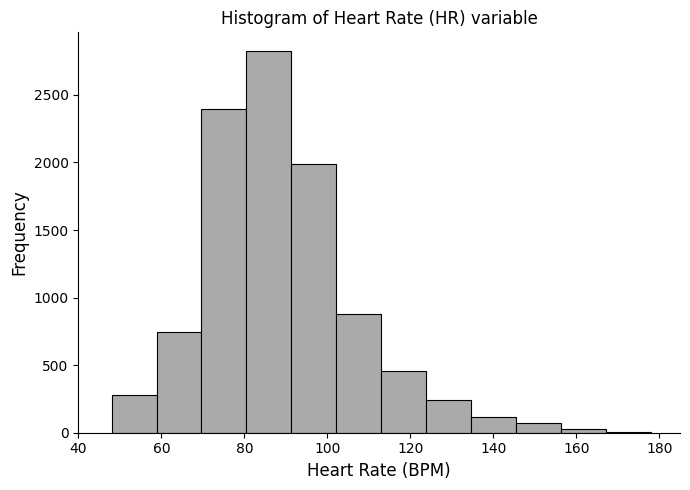

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_3_window_stats_filled.parquet")

bpm_per_recording = df.groupby("file_name")["bpm"].first()

print(f"Number of unique recordings: {len(bpm_per_recording)}")
print(f"BPM range: {bpm_per_recording.min()} – {bpm_per_recording.max()}")

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(bpm_per_recording, bins=12, color="#aaaaaa", edgecolor="black", linewidth=0.8)

ax.set_xlabel("Heart Rate (BPM)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Histogram of Heart Rate (HR) variable", fontsize=12)
ax.set_xlim(40, 185)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/hr_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

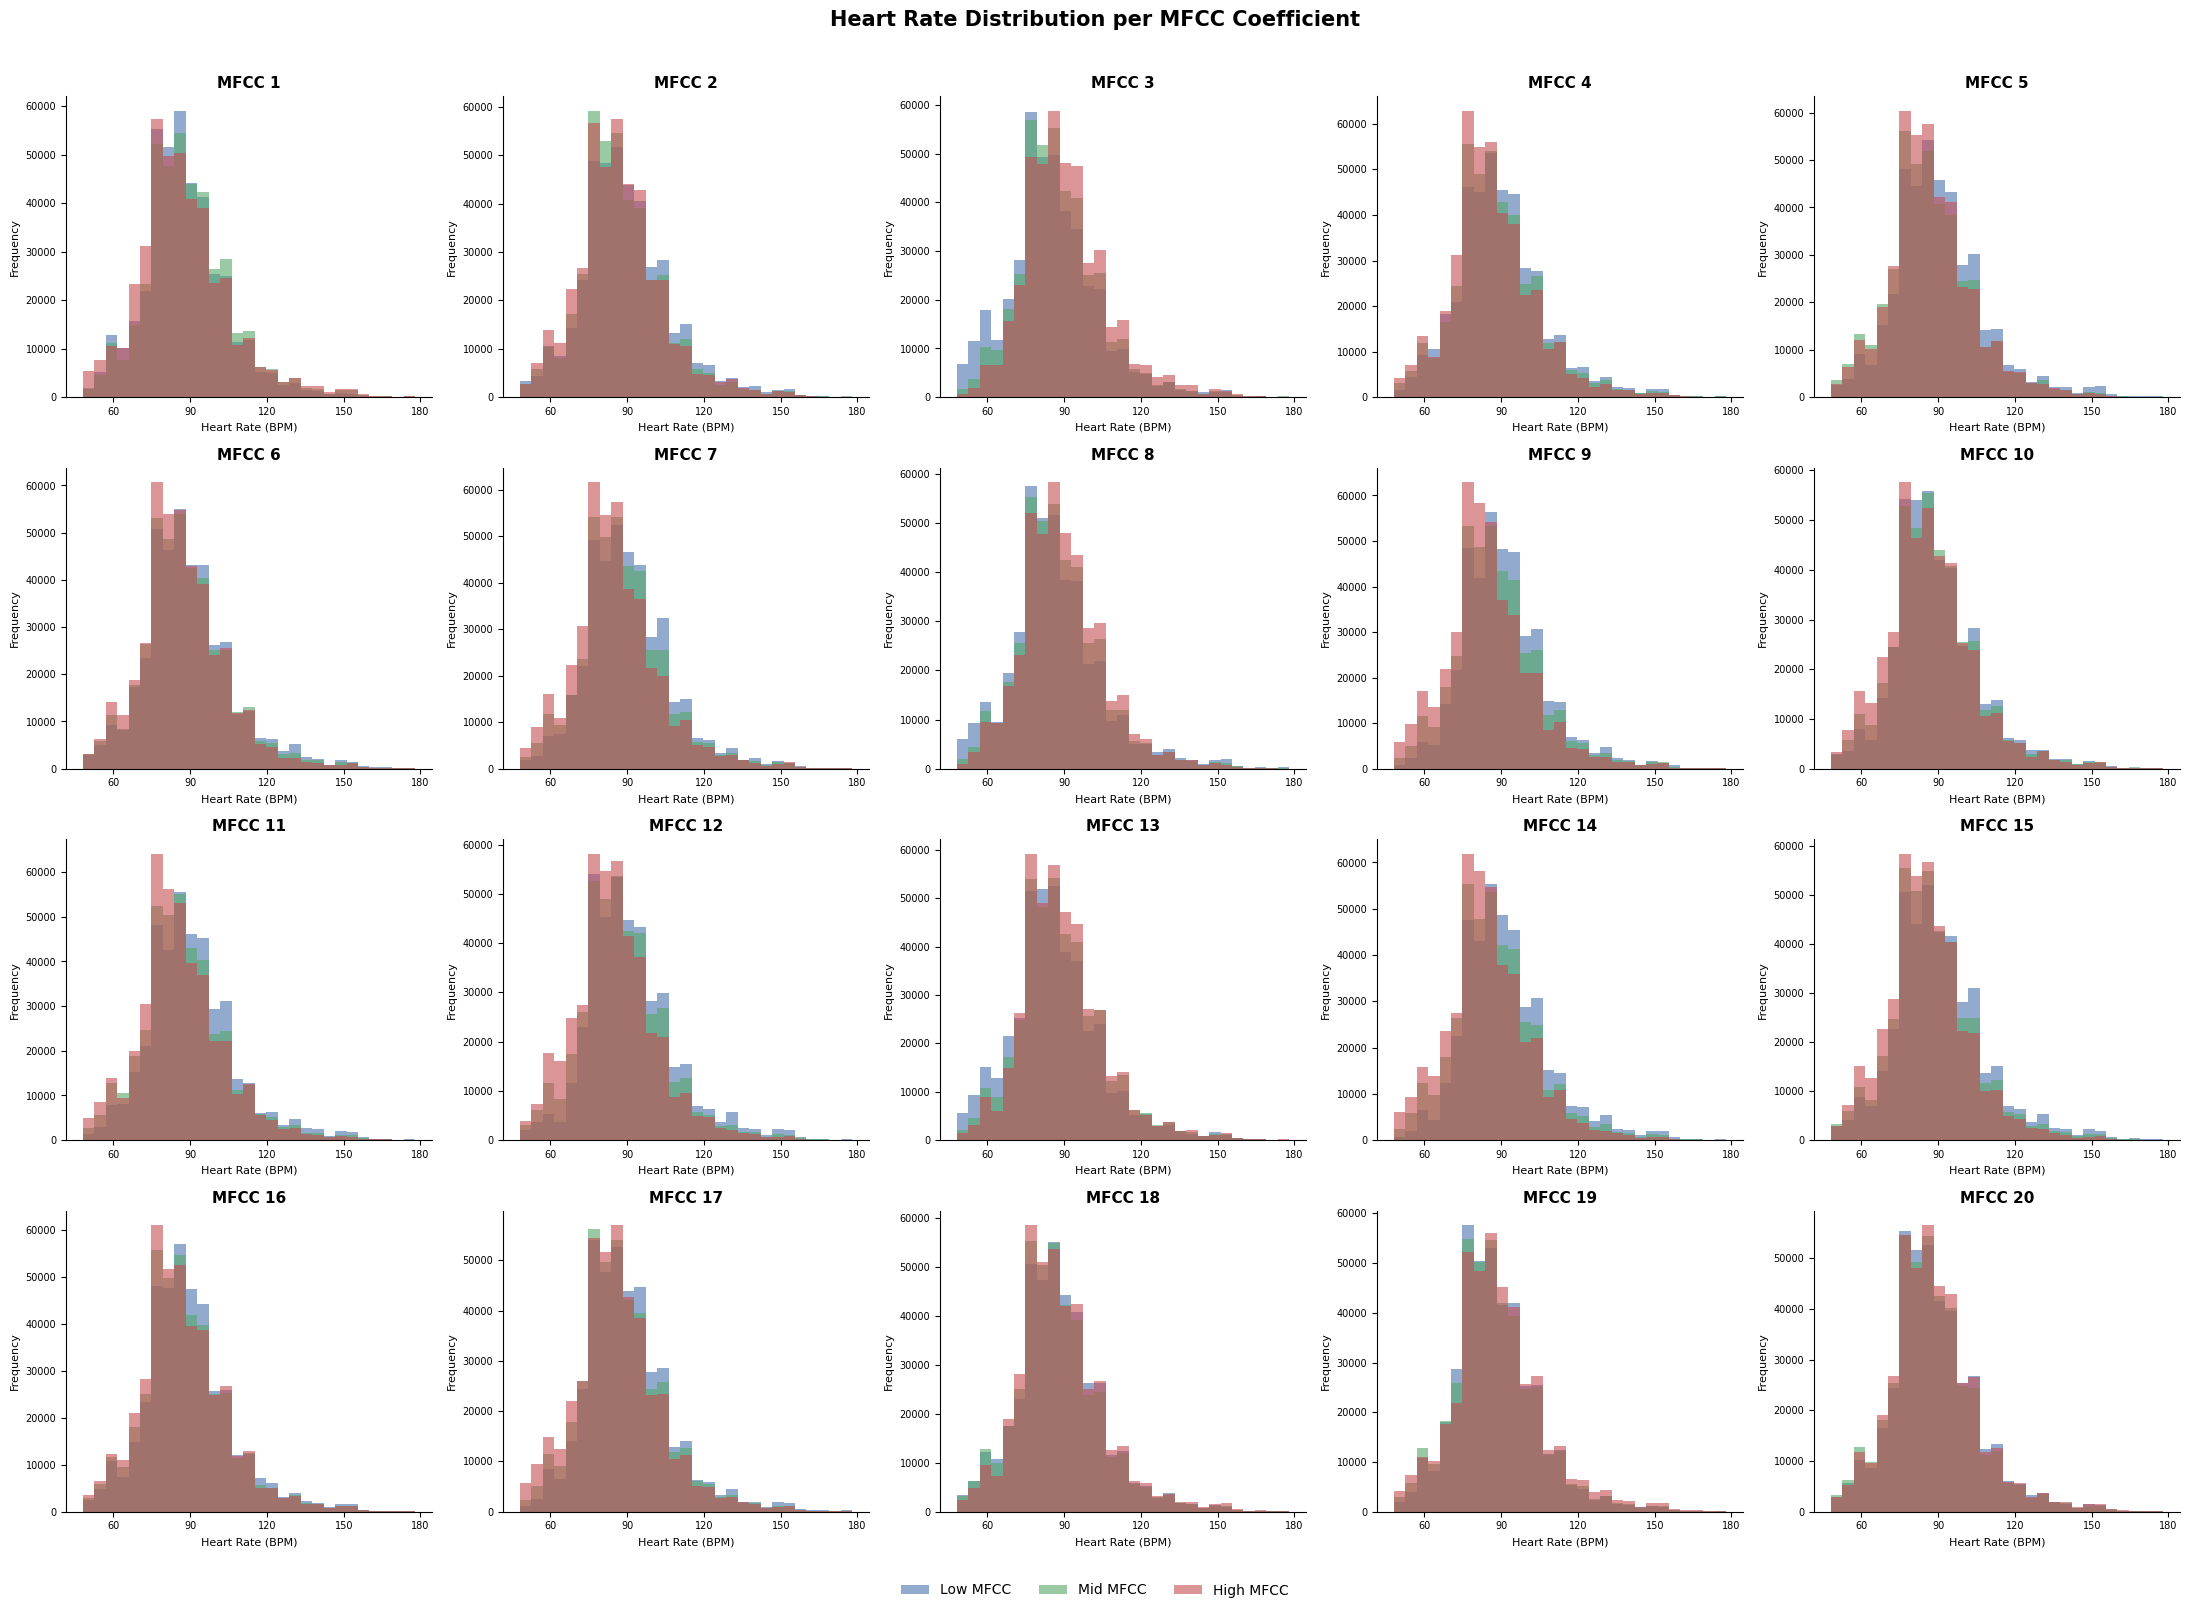

Saved: hr_mfcc_histograms.png


In [76]:
import matplotlib.ticker as ticker
import numpy as np

df_plot = df[["file_name"] + [f"mfcc_{i}" for i in range(1, 21)]].merge(bpm_per_recording, on="file_name")

mfcc_cols = [f"mfcc_{i}" for i in range(1, 21)]

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

bpm_min = df_plot["bpm"].min()
bpm_max = df_plot["bpm"].max()
bins = np.linspace(bpm_min, bpm_max, 30)

for idx, col in enumerate(mfcc_cols):
    ax = axes[idx]

    # Quartile-based colouring
    q1 = df_plot[col].quantile(0.33)
    q2 = df_plot[col].quantile(0.66)

    low  = df_plot[df_plot[col] <= q1]["bpm"]
    mid  = df_plot[(df_plot[col] > q1) & (df_plot[col] <= q2)]["bpm"]
    high = df_plot[df_plot[col] > q2]["bpm"]

    ax.hist(low,  bins=bins, alpha=0.6, color="#4C72B0", label="Low MFCC")
    ax.hist(mid,  bins=bins, alpha=0.6, color="#55A868", label="Mid MFCC")
    ax.hist(high, bins=bins, alpha=0.6, color="#C44E52", label="High MFCC")

    ax.set_title(f"MFCC {idx + 1}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Heart Rate (BPM)", fontsize=8)
    ax.set_ylabel("Frequency", fontsize=8)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

# Shared legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, 0.01))

fig.suptitle("Heart Rate Distribution per MFCC Coefficient", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/hr_mfcc_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hr_mfcc_histograms.png")

### MinMax Normalisation 

Based on Usman et. al. 2021, formula: Normalized value = x − min(x) / [max(x) − min(x)]. Normalised **per speaker and per column**. 

Entropy statistics:

 (specifically Shannon entropy) measures the uncertainty or unpredictability in a system, yielding non-negative values that represent the average information content. It ranges from 0 (perfect certainty) up to logb(m), where m is the number of possible outcomes

 Skewness:

Skewness is a statistical measure of the asymmetry of a probability distribution around its mean. While theoretical skewness can range from negative infinity to positive infinity, in practical data analysis, it is usually interpreted within a specific range, often -3 to +3, with specific thresholds used to determine the severity of asymmetry.

Kurtosis:

Kurtosis measures the "tailedness" of a distribution, with values typically ranging from 1 to positive infinity. A normal distribution has a kurtosis of 3 (mesokurtic). Values < 3 indicate lighter tails (platykurtic), while values > 3 indicate heavier tails (leptokurtic).




In [49]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_3_window_stats_filled.parquet")

cols_of_interest = df.drop(columns=["file_name", "frame_idx", "bpm"]).columns

# Save file_name BEFORE groupby so we can reattach it afterwards
file_name_backup = df["file_name"].values.copy()

# Derive a language-independent speaker key from the file name.
# Example: "En026F220722R130.ogg" -> "026F"
# Characters 2–5 (0-indexed) give the 3-digit speaker number + gender letter,
# which stays the same for a given speaker across Tamil and English recordings.
speaker_key = df["file_name"].str[2:6]

def minmax_normalise(group):
    group = group.copy()
    for col in cols_of_interest:
        col_min = group[col].min()
        col_max = group[col].max()
        denom = col_max - col_min
        if denom == 0:
            group[col] = 0.0
        else:
            group[col] = (group[col] - col_min) / denom
    return group

# Group by the speaker key (not stored in the dataframe), so all recordings
# of the same speaker across both languages share the same min/max per column.
df = df.groupby(speaker_key, group_keys=False).apply(minmax_normalise)

# Reattach file_name in the original order
df = df.reset_index(drop=True)
df["file_name"] = file_name_backup

# Put file_name first for readability
df = df[["file_name"] + [c for c in df.columns if c != "file_name"]]

df.to_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet", index=False)

print(f"Done! Normalised {len(cols_of_interest)} raw columns per speaker. Shape: {df.shape}")
print(f"Number of unique speakers: {speaker_key.nunique()}")
print("\n-- cols_of_interest (should be 0–1) --")
print(df[cols_of_interest].describe().loc[["min", "max"]])
print("\n-- BPM (should be untouched) --")
print(df["bpm"].describe())

Done! Normalised 92 raw columns per speaker. Shape: (1252312, 95)
Number of unique speakers: 109

-- cols_of_interest (should be 0–1) --
     mfcc_1  mfcc_2  mfcc_3  mfcc_4  mfcc_5  mfcc_6  mfcc_7  mfcc_8  mfcc_9  \
min  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
max  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   

     mfcc_10  mfcc_11  mfcc_12  mfcc_13  mfcc_14  mfcc_15  mfcc_16  mfcc_17  \
min   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   
max   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   

     mfcc_18  mfcc_19  mfcc_20  pitch  jitter  shimmer  mfcc_1_entropy  \
min   0.0000   0.0000   0.0000 0.0000  0.0000   0.0000          0.0000   
max   1.0000   1.0000   1.0000 1.0000  1.0000   1.0000          1.0000   

     mfcc_1_kurtosis  mfcc_1_skewness  mfcc_2_entropy  mfcc_2_kurtosis  \
min           0.0000           0.0000          0.0000           0.0000   
max           1.

### Test normalisation without entropy, skew and kurtosis

In [50]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_3_window_stats_filled.parquet")

cols_of_interest = [f"mfcc_{i}" for i in range(1, 21)] + ["pitch", "jitter", "shimmer"]

# Save file_name BEFORE groupby so we can reattach it afterwards
file_name_backup = df["file_name"].values.copy()

# Derive a language-independent speaker key from the file name.
# Example: "En026F220722R130.ogg" -> "026F"
# Characters 2–5 (0-indexed) give the 3-digit speaker number + gender letter,
# which stays the same for a given speaker across Tamil and English recordings.
speaker_key = df["file_name"].str[2:6]

def minmax_normalise(group):
    group = group.copy()
    for col in cols_of_interest:
        col_min = group[col].min()
        col_max = group[col].max()
        denom = col_max - col_min
        if denom == 0:
            group[col] = 0.0
        else:
            group[col] = (group[col] - col_min) / denom
    return group

# Group by the speaker key (not stored in the dataframe), so all recordings
# of the same speaker across both languages share the same min/max per column.
df = df.groupby(speaker_key, group_keys=False).apply(minmax_normalise)

# Reattach file_name in the original order
df = df.reset_index(drop=True)
df["file_name"] = file_name_backup

# Put file_name first for readability
df = df[["file_name"] + [c for c in df.columns if c != "file_name"]]

df.to_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_5_test_normalisation.parquet", index=False)

print(f"Done! Normalised {len(cols_of_interest)} raw columns per speaker. Shape: {df.shape}")
print(f"Number of unique speakers: {speaker_key.nunique()}")
print("\n-- cols_of_interest (should be 0–1) --")
print(df[cols_of_interest].describe().loc[["min", "max"]])
print("\n-- BPM (should be untouched) --")
print(df["bpm"].describe())

Done! Normalised 23 raw columns per speaker. Shape: (1252312, 95)
Number of unique speakers: 109

-- cols_of_interest (should be 0–1) --
     mfcc_1  mfcc_2  mfcc_3  mfcc_4  mfcc_5  mfcc_6  mfcc_7  mfcc_8  mfcc_9  \
min  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
max  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   

     mfcc_10  mfcc_11  mfcc_12  mfcc_13  mfcc_14  mfcc_15  mfcc_16  mfcc_17  \
min   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   
max   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   

     mfcc_18  mfcc_19  mfcc_20  pitch  jitter  shimmer  
min   0.0000   0.0000   0.0000 0.0000  0.0000   0.0000  
max   1.0000   1.0000   1.0000 1.0000  1.0000   1.0000  

-- BPM (should be untouched) --
count   1252312.0000
mean         88.2037
std          17.1836
min          48.0000
25%          77.0000
50%          86.0000
75%          97.0000
max         178.0000
Name: bpm, dtyp

In [23]:
df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
pd.set_option("display.max_columns", None)
print(df.head())

              file_name  frame_idx  mfcc_1  mfcc_2  mfcc_3  mfcc_4  mfcc_5  \
0  En001M240401A083.ogg          0  0.7849  0.2669  0.4113  0.4503  0.4612   
1  En001M240401A083.ogg          1  0.7908  0.1812  0.6004  0.4147  0.4591   
2  En001M240401A083.ogg          2  0.7807  0.1332  0.5887  0.5038  0.4605   
3  En001M240401A083.ogg          3  0.8105  0.1693  0.6339  0.4811  0.4660   
4  En001M240401A083.ogg          4  0.8333  0.3513  0.6220  0.6014  0.5639   

   mfcc_6  mfcc_7  mfcc_8  mfcc_9  mfcc_10  mfcc_11  mfcc_12  mfcc_13  \
0  0.4746  0.5941  0.5748  0.5732   0.5814   0.4272   0.6706   0.4873   
1  0.5637  0.5078  0.5914  0.5314   0.5528   0.3849   0.6528   0.5172   
2  0.5496  0.6952  0.5672  0.4645   0.5144   0.2986   0.5709   0.5506   
3  0.4986  0.6460  0.5748  0.5643   0.6203   0.3689   0.5561   0.4612   
4  0.4430  0.5598  0.4668  0.5550   0.6092   0.2846   0.5173   0.5443   

   mfcc_14  mfcc_15  mfcc_16  mfcc_17  mfcc_18  mfcc_19  mfcc_20  pitch  \
0   0.5379   0.73

### Missing values inspection

In [24]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")

all_cols = [c for c in df.columns if c not in ("file_name", "frame_idx", "bpm")]

# Overall NaN count per column
overall_nans = df.isna().sum()
print("=== Overall NaN count ===")
print(overall_nans[overall_nans > 0].to_string() if overall_nans.sum() > 0 else "No NaNs found")


=== Overall NaN count ===
No NaNs found


# Exploratory Data Analysis

In [53]:
import pandas as pd

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
df.head()

,file_name,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm
0,En001M240401A083.ogg,0,0.7849,0.2669,0.4113,0.4503,0.4612,0.4746,0.5941,0.5748,0.5732,0.5814,0.4272,0.6706,0.4873,0.5379,0.7363,0.6437,0.5866,0.5846,0.4808,0.5650,0.0000,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
1,En001M240401A083.ogg,1,0.7908,0.1812,0.6004,0.4147,0.4591,0.5637,0.5078,0.5914,0.5314,0.5528,0.3849,0.6528,0.5172,0.5171,0.6419,0.4883,0.6400,0.5952,0.4046,0.5316,0.0000,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
2,En001M240401A083.ogg,2,0.7807,0.1332,0.5887,0.5038,0.4605,0.5496,0.6952,0.5672,0.4645,0.5144,0.2986,0.5709,0.5506,0.5690,0.6522,0.5057,0.6197,0.5280,0.4263,0.6465,0.5646,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
3,En001M240401A083.ogg,3,0.8105,0.1693,0.6339,0.4811,0.4660,0.4986,0.6460,0.5748,0.5643,0.6203,0.3689,0.5561,0.4612,0.6280,0.5815,0.4949,0.7322,0.5926,0.3445,0.6811,0.5602,0.0000,0.0000,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83
4

### Summary statistics

In [26]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Total number of frames: {len(df)}")

frames_per_recording = df.groupby("file_name")["frame_idx"].count()

print(f"Min frames:    {frames_per_recording.min()}")
print(f"Max frames:    {frames_per_recording.max()}")
print(f"Median frames: {frames_per_recording.median()}")

Shape: (1252312, 95)
Columns: ['file_name', 'frame_idx', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15', 'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'mfcc_20', 'pitch', 'jitter', 'shimmer', 'mfcc_1_entropy', 'mfcc_1_kurtosis', 'mfcc_1_skewness', 'mfcc_2_entropy', 'mfcc_2_kurtosis', 'mfcc_2_skewness', 'mfcc_3_entropy', 'mfcc_3_kurtosis', 'mfcc_3_skewness', 'mfcc_4_entropy', 'mfcc_4_kurtosis', 'mfcc_4_skewness', 'mfcc_5_entropy', 'mfcc_5_kurtosis', 'mfcc_5_skewness', 'mfcc_6_entropy', 'mfcc_6_kurtosis', 'mfcc_6_skewness', 'mfcc_7_entropy', 'mfcc_7_kurtosis', 'mfcc_7_skewness', 'mfcc_8_entropy', 'mfcc_8_kurtosis', 'mfcc_8_skewness', 'mfcc_9_entropy', 'mfcc_9_kurtosis', 'mfcc_9_skewness', 'mfcc_10_entropy', 'mfcc_10_kurtosis', 'mfcc_10_skewness', 'mfcc_11_entropy', 'mfcc_11_kurtosis', 'mfcc_11_skewness', 'mfcc_12_entropy', 'mfcc_12_kurtosis', 'mfcc_12_skewness', 'mfcc_13_entropy', 'm

In [27]:
df.describe()

,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm
count,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000,1252312.0000
mean,103.7590,0.6119,0.6489,0.4767,0.4958,0.5256,0.5025,0.4880,0.5216,0.4983,0.4955,0.4907,0.5069,0.5155,0.5070,0.4982,0.4924,0.5062,0.4996,0.4976,0.5022,0.4909,0.0281,0.1218,0.7532,0.2298,0.4640,0.6475,0.2330,0.5147,0.6651,0.2809,0.4957,0.6947,0.2612,0.4948,0.6820,0.2781,0.4907,0.6708,0.2795,0.5033,0.6435,0.2926,0.5102,0.6446,0.2861,0.5048,0.6430,0.3019,0.4920,0.6337,0.3011,0.4950,0.6433,0.2924,0.5159,0.6489,0.2868,0.4975,0.6324,0.3161,0.4866,0.6226,0.2974,0.5003,0.6241,0.2935,0.4898,0.6206,0.3053,0.5062,0.6285,0.3045,0.4984,0.6249,0.2974,0.5081,0.6250,0.3020,0.4992,0.6272,0.3026,0.5023,0.3817,0.0774,0.5836,0.5879,0.1750,0.3284,0.6575,0.1967,0.3746,88.2037
std,118.5381,0.1874,0.1576,0.1413,0.1531,0.1446,0.1495,0.1375,0.1352,0.1387,0.1325,0.1346,0.1356,0.1324,0.1322,0.1319,0.1301,0.1294,0.1311,0.1309,0.1296,0.3408,0.0532,0.1414,0.1848,0.1813,0.1925,0.2010,0.1770,0.1863,0.1973,0.1752,0.1890,0.1941,0.1753,0.1865,0.1929,0.1757,0.1846,0.1961,0.1705,0.1853,0.1967,0.1719,0.1859,0.1956,0.1729,0.1794,0.1948,0.1717,0.1809,0.1987,0.1740,0.1831,0.1945,0.1739,0.1820,0.1938,0.1697,0.1795,0.1957,0.1792,0.1835,0.1969,0.1686,0.1794,0.1972,0.1731,0.1817,0.1953,0.1747,0.1847,0.1941,0.1729,0.1840,0.1979,0.1696,0.1819,0.1958,0.1698,0.1828,0.1919,0.1724,0.1804,0.1835,0.1415,0.1827,0.2148,0.1734,0.1840,0.1985,0.1795,0.1914,17.1836
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1252312 entries, 0 to 1252311
Data columns (total 95 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   file_name         1252312 non-null  str    
 1   frame_idx         1252312 non-null  int32  
 2   mfcc_1            1252312 non-null  float32
 3   mfcc_2            1252312 non-null  float32
 4   mfcc_3            1252312 non-null  float32
 5   mfcc_4            1252312 non-null  float32
 6   mfcc_5            1252312 non-null  float32
 7   mfcc_6            1252312 non-null  float32
 8   mfcc_7            1252312 non-null  float32
 9   mfcc_8            1252312 non-null  float32
 10  mfcc_9            1252312 non-null  float32
 11  mfcc_10           1252312 non-null  float32
 12  mfcc_11           1252312 non-null  float32
 13  mfcc_12           1252312 non-null  float32
 14  mfcc_13           1252312 non-null  float32
 15  mfcc_14           1252312 non-null  float32
 16  mfcc_15    

### Distribution of features 

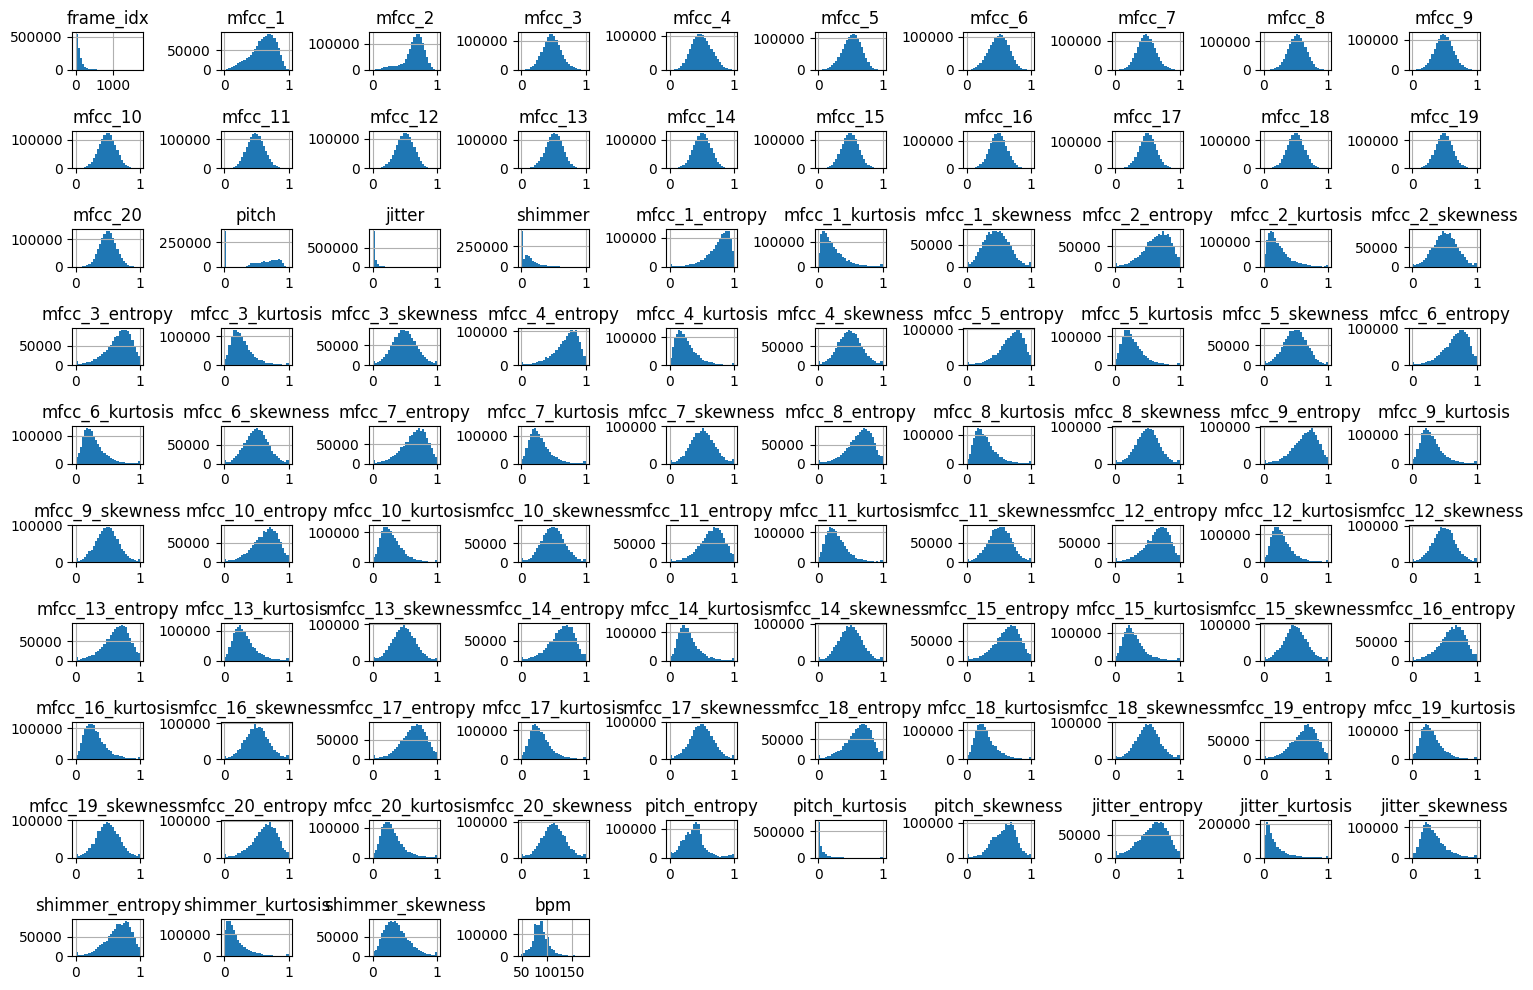

In [29]:
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Beats Per Minute (per frame)')

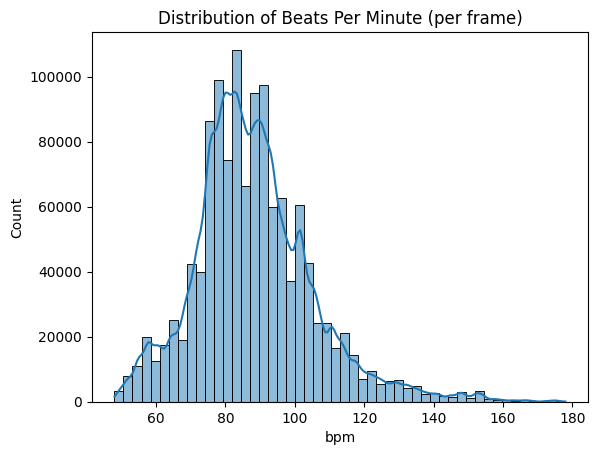

In [59]:
# Checking the distribution of the target (per frame)
import seaborn as sns

hist = sns.histplot(df['bpm'], bins=50, kde=True)
plt.title('Distribution of Beats Per Minute (per frame)')

bpm
48       2
49       3
50       7
51      14
52      21
53      16
54      25
55      35
56      34
57      62
58      57
59      43
60      55
61      46
62      50
63      46
64      71
65      63
66      72
67      68
68     104
69     125
70     123
71     148
72     176
73     189
74     186
75     244
76     263
77     245
78     264
79     276
80     284
81     290
82     243
83     283
84     247
85     265
86     243
87     233
88     250
89     234
90     266
91     268
92     243
93     223
94     253
95     155
96     189
97     163
98     143
99     155
100    122
101    170
102    175
103    132
104    112
105    121
106    103
107     82
108     75
109     53
110     73
111     81
112     46
113     71
114     51
115     62
116     36
117     46
118     42
119     29
120     33
121     29
122     33
123     24
124     29
125     28
126     24
127     24
128     17
129     25
130     25
131     13
132     27
133     16
134     17
135     17
136     20
137      9
138   

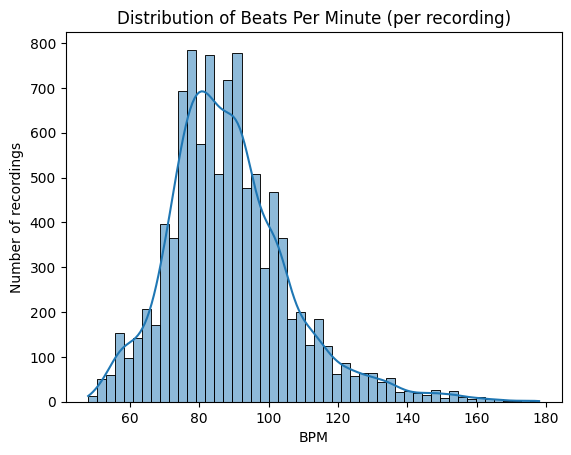

In [57]:
# Checking the distribution of the target (one value per recording)
import seaborn as sns
import matplotlib.pyplot as plt

# Collapse to one row per recording so each recording contributes its BPM once,
# regardless of how many frames/windows it was split into after feature extraction.
bpm_per_recording = df.groupby("file_name")["bpm"].first()

target_distribution = bpm_per_recording.value_counts(normalize=False)
print(target_distribution.sort_index())

hist = sns.histplot(bpm_per_recording, bins=50, kde=True)
plt.title('Distribution of Beats Per Minute (per recording)')
plt.xlabel('BPM')
plt.ylabel('Number of recordings')
plt.show()

Distribution Characteristics: 

- Range: 48–178 BPM, spanning both resting and elevated heart rates
- Central tendency: Peak around 80–90 BPM, consistent with normal resting/light activity HR
- Shape: Right-skewed — the bulk of recordings cluster between 70–100 BPM with a long tail extending to 178
- Spread: 126 unique BPM values indicating good variability across participants and conditions
- Multimodal hint: A secondary bump is visible around 95–100 BPM, likely reflecting the post-walking and emotion-inducing conditions in the dataset design

Text(0.5, 1.0, 'Beats Per Minute Scatter Plot')

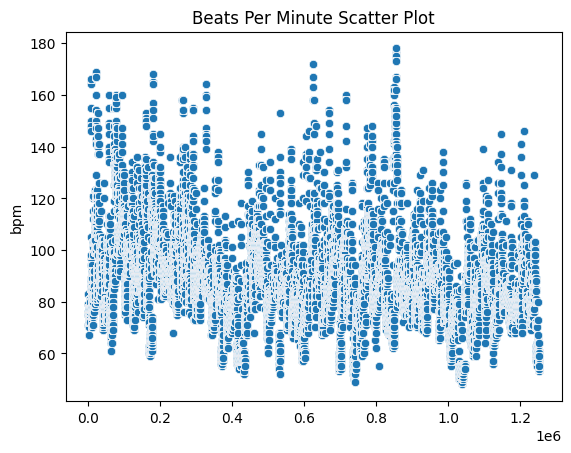

In [31]:
scatter = sns.scatterplot(df['bpm'])
plt.title('Beats Per Minute Scatter Plot')

In [32]:
# Statistics on bpm
df["bpm"].describe()

count   1252312.0000
mean         88.2037
std          17.1836
min          48.0000
25%          77.0000
50%          86.0000
75%          97.0000
max         178.0000
Name: bpm, dtype: float64

### Checking correlations 

In [33]:
# Spearman correlation 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
cor_m = numeric_df.corr(method="spearman")
print(cor_m)

                  frame_idx  mfcc_1  mfcc_2  mfcc_3  mfcc_4  mfcc_5  mfcc_6  \
frame_idx            1.0000 -0.1742  0.0402 -0.0010 -0.0331  0.0665  0.0375   
mfcc_1              -0.1742  1.0000 -0.2370 -0.2058  0.0809 -0.3372 -0.3095   
mfcc_2               0.0402 -0.2370  1.0000 -0.2210 -0.0521  0.0075  0.0561   
mfcc_3              -0.0010 -0.2058 -0.2210  1.0000  0.0322  0.1692 -0.0031   
mfcc_4              -0.0331  0.0809 -0.0521  0.0322  1.0000 -0.1672 -0.4561   
mfcc_5               0.0665 -0.3372  0.0075  0.1692 -0.1672  1.0000  0.1065   
mfcc_6               0.0375 -0.3095  0.0561 -0.0031 -0.4561  0.1065  1.0000   
mfcc_7              -0.0317  0.0046  0.0951 -0.0259 -0.0772 -0.0590  0.0404   
mfcc_8               0.0322 -0.0234 -0.1934 -0.0250 -0.0736  0.0702  0.0114   
mfcc_9               0.0150  0.2378 -0.0754 -0.2628 -0.0395 -0.0542 -0.0375   
mfcc_10              0.0539  0.0132  0.0219 -0.0371 -0.1496 -0.0133  0.0450   
mfcc_11              0.0236  0.1080  0.0366  0.0542 

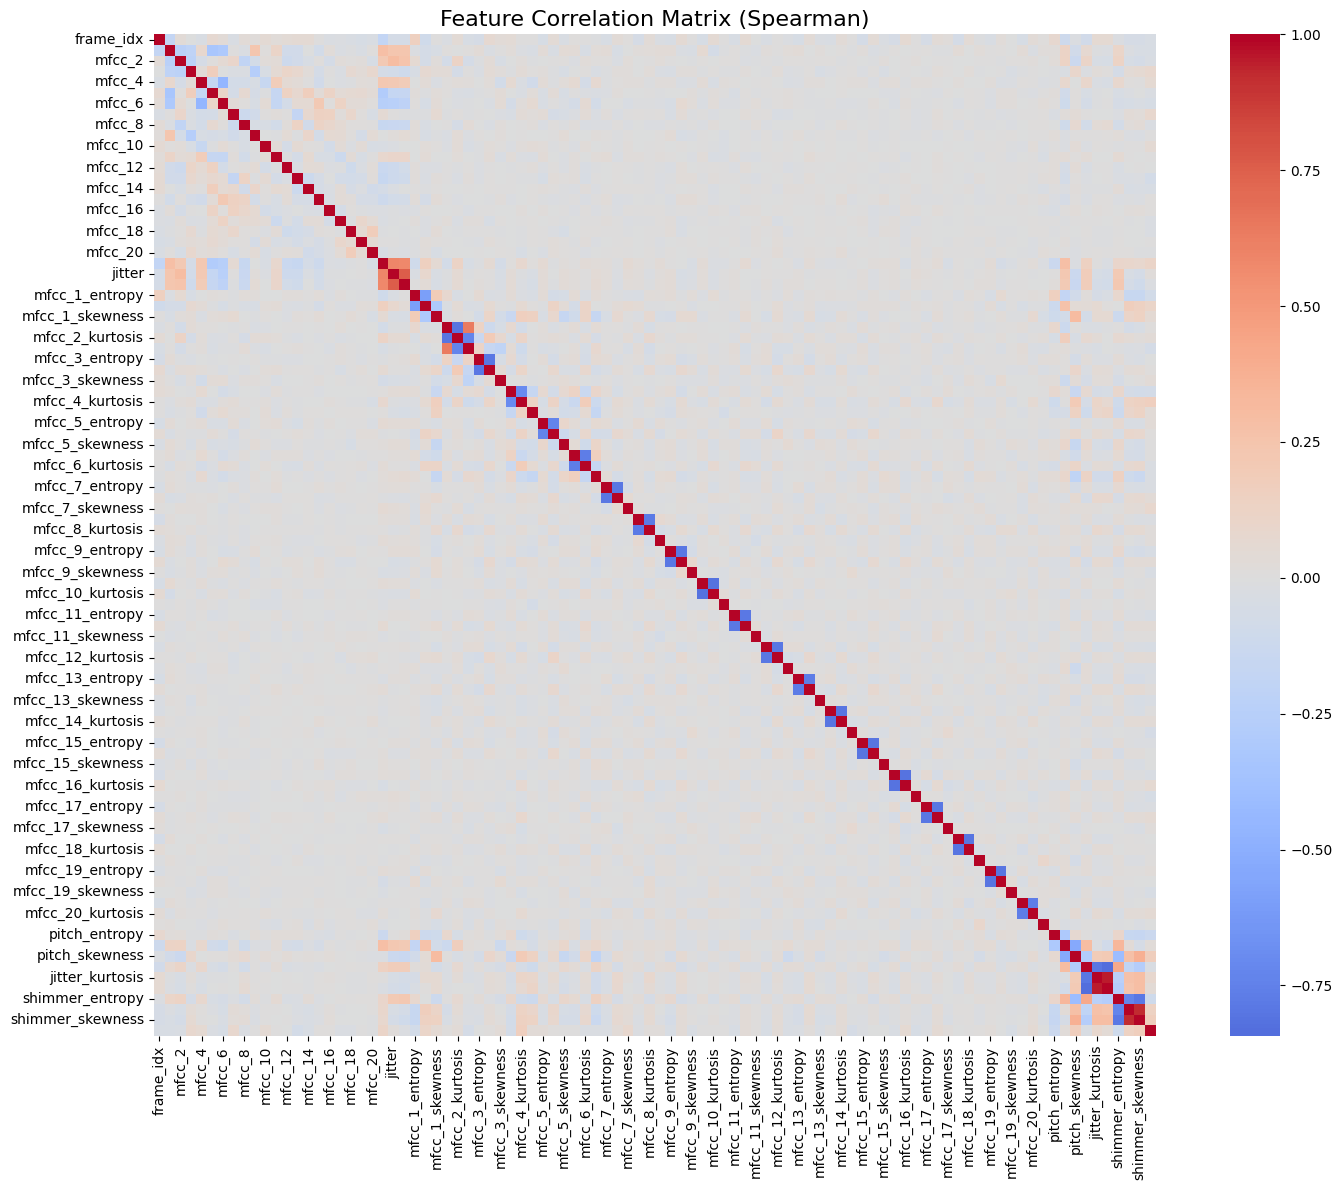

In [34]:
# Correlation heatmap

plt.figure(figsize=(16, 12))
sns.heatmap(cor_m, annot=False, cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix (Spearman)", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [61]:
# Highest correlated feature pairs (|r| >= 0.75)
threshold = 0.75
num_cols = df.select_dtypes(include=['int', 'float']).columns
cols = list(num_cols)  # Convert to list directly from num_cols
pairs = []

# pairwise correlations computed on the fly (no full corr matrix)
for i in range(len(cols)):
    xi = df[cols[i]]
    if xi.nunique(dropna=True) <= 1:
        continue
    for j in range(i + 1, len(cols)):
        xj = df[cols[j]]
        if xj.nunique(dropna=True) <= 1:
            continue
        corr = xi.corr(xj)  # Pearson by default
        if pd.isna(corr):
            continue
        if abs(corr) >= threshold:
            pairs.append((cols[i], cols[j], float(corr)))

# sort by absolute correlation descending and print
pairs.sort(key=lambda t: -abs(t[2]))

total_cor = 0

print(f"\n--- Feature Correlations (|r| >= {threshold}) ---")
if pairs:
    print(f"Found {len(pairs)} correlated pairs:\n")
    for a, b, c in pairs:
        print(f"  {a:25s} <> {b:25s}: {c:+.4f}")
        total_cor += c
else:
    print(f"No variable pairs found with |corr| >= {threshold}")
print(f"Mean high correlation = {total_cor/len(pairs)}")
# --- Share of the dataset involved in highly correlated pairs ---
total_numeric_features = len(cols)
total_possible_pairs = total_numeric_features * (total_numeric_features - 1) // 2

# Unique features that appear in at least one highly correlated pair
features_in_pairs = set()
for a, b, _ in pairs:
    features_in_pairs.add(a)
    features_in_pairs.add(b)

pct_pairs = 100 * len(pairs) / total_possible_pairs if total_possible_pairs > 0 else 0.0
pct_features = 100 * len(features_in_pairs) / total_numeric_features if total_numeric_features > 0 else 0.0

print(f"\n--- Dataset Coverage of Highly Correlated Pairs ---")
print(f"Total numeric features:           {total_numeric_features}")
print(f"Total possible feature pairs:     {total_possible_pairs}")
print(f"Highly correlated pairs found:    {len(pairs)} ({pct_pairs:.2f}% of all pairs)")
print(f"Unique features in those pairs:   {len(features_in_pairs)} ({pct_features:.2f}% of all features)")


--- Feature Correlations (|r| >= 0.75) ---
Found 24 correlated pairs:

  jitter_kurtosis           <> jitter_skewness          : +0.9549
  shimmer_kurtosis          <> shimmer_skewness         : +0.9125
  jitter_entropy            <> jitter_skewness          : -0.8720
  mfcc_14_entropy           <> mfcc_14_kurtosis         : -0.8674
  mfcc_8_entropy            <> mfcc_8_kurtosis          : -0.8643
  mfcc_20_entropy           <> mfcc_20_kurtosis         : -0.8636
  mfcc_16_entropy           <> mfcc_16_kurtosis         : -0.8636
  mfcc_18_entropy           <> mfcc_18_kurtosis         : -0.8634
  mfcc_17_entropy           <> mfcc_17_kurtosis         : -0.8625
  mfcc_15_entropy           <> mfcc_15_kurtosis         : -0.8625
  mfcc_13_entropy           <> mfcc_13_kurtosis         : -0.8624
  mfcc_19_entropy           <> mfcc_19_kurtosis         : -0.8622
  mfcc_10_entropy           <> mfcc_10_kurtosis         : -0.8620
  mfcc_11_entropy           <> mfcc_11_kurtosis         : -0.8618
  mf

# Results correlation: 

entropy and kurtosis are highly (negatively) correlated

Both measure "peakedness" vs. "spread" of a distribution — in opposite directions. Entropy and kurtosis are not independent descriptors; they are two different lenses on the same underlying property of a distribution: how concentrated vs. how spread out the values are.

Drop one of them? The models should handle this but SHAP can flag the importance wrongly

## Without normailising entropy etc:

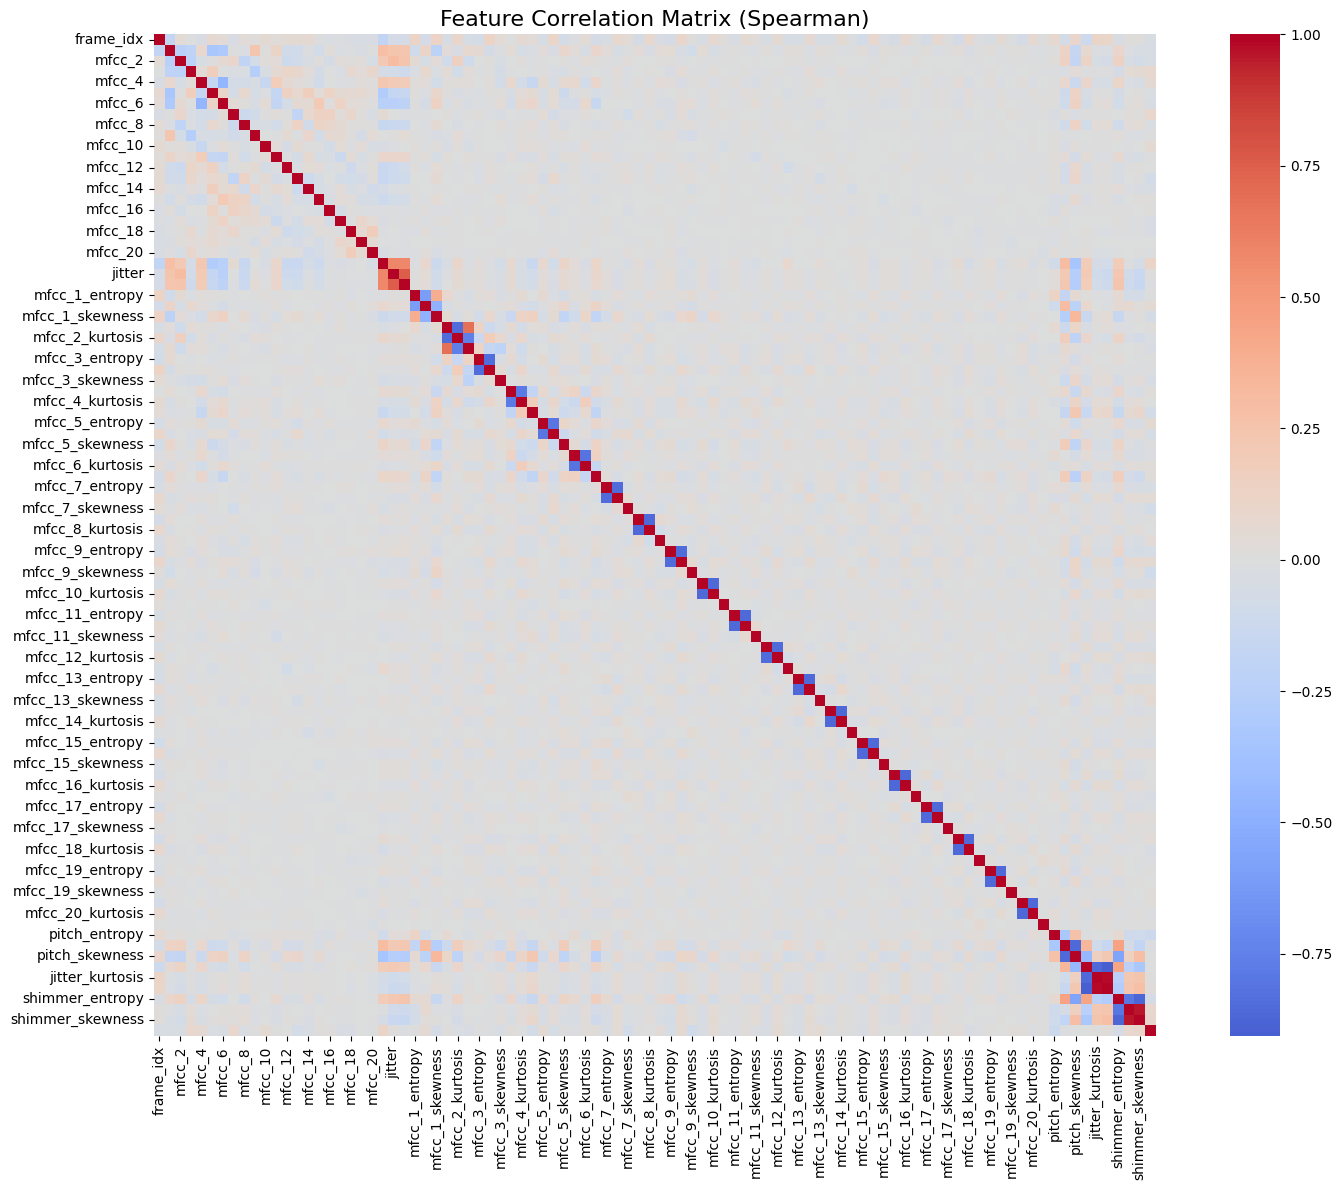

In [55]:
# Spearman correlation 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

test_df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_5_test_normalisation.parquet")

# Select only numeric columns for correlation
numeric_df = test_df.select_dtypes(include=[np.number])
cor_m = numeric_df.corr(method="spearman")

# Correlation heatmap

plt.figure(figsize=(16, 12))
sns.heatmap(cor_m, annot=False, cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix (Spearman)", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
# Highest correlated feature pairs (|r| >= 0.75)
threshold = 0.75
num_cols = test_df.select_dtypes(include=['int', 'float']).columns
cols = list(num_cols)  # Convert to list directly from num_cols
pairs = []

# pairwise correlations computed on the fly (no full corr matrix)
for i in range(len(cols)):
    xi = test_df[cols[i]]
    if xi.nunique(dropna=True) <= 1:
        continue
    for j in range(i + 1, len(cols)):
        xj = test_df[cols[j]]
        if xj.nunique(dropna=True) <= 1:
            continue
        corr = xi.corr(xj)  # Pearson by default
        if pd.isna(corr):
            continue
        if abs(corr) >= threshold:
            pairs.append((cols[i], cols[j], float(corr)))

# sort by absolute correlation descending and print
pairs.sort(key=lambda t: -abs(t[2]))

print(f"\n--- Feature Correlations (|r| >= {threshold}) ---")
if pairs:
    print(f"Found {len(pairs)} correlated pairs:\n")
    for a, b, c in pairs:
        print(f"  {a:25s} <> {b:25s}: {c:+.4f}")
else:
    print(f"No variable pairs found with |corr| >= {threshold}")

# --- Share of the dataset involved in highly correlated pairs ---
total_numeric_features = len(cols)
total_possible_pairs = total_numeric_features * (total_numeric_features - 1) // 2

# Unique features that appear in at least one highly correlated pair
features_in_pairs = set()
for a, b, _ in pairs:
    features_in_pairs.add(a)
    features_in_pairs.add(b)

pct_pairs = 100 * len(pairs) / total_possible_pairs if total_possible_pairs > 0 else 0.0
pct_features = 100 * len(features_in_pairs) / total_numeric_features if total_numeric_features > 0 else 0.0

print(f"\n--- Dataset Coverage of Highly Correlated Pairs ---")
print(f"Total numeric features:           {total_numeric_features}")
print(f"Total possible feature pairs:     {total_possible_pairs}")
print(f"Highly correlated pairs found:    {len(pairs)} ({pct_pairs:.2f}% of all pairs)")
print(f"Unique features in those pairs:   {len(features_in_pairs)} ({pct_features:.2f}% of all features)")


--- Feature Correlations (|r| >= 0.75) ---
Found 24 correlated pairs:

  jitter_kurtosis           <> jitter_skewness          : +0.9549
  shimmer_kurtosis          <> shimmer_skewness         : +0.9125
  jitter_entropy            <> jitter_skewness          : -0.8720
  mfcc_14_entropy           <> mfcc_14_kurtosis         : -0.8674
  mfcc_8_entropy            <> mfcc_8_kurtosis          : -0.8643
  mfcc_20_entropy           <> mfcc_20_kurtosis         : -0.8636
  mfcc_16_entropy           <> mfcc_16_kurtosis         : -0.8636
  mfcc_18_entropy           <> mfcc_18_kurtosis         : -0.8634
  mfcc_17_entropy           <> mfcc_17_kurtosis         : -0.8625
  mfcc_15_entropy           <> mfcc_15_kurtosis         : -0.8625
  mfcc_13_entropy           <> mfcc_13_kurtosis         : -0.8624
  mfcc_19_entropy           <> mfcc_19_kurtosis         : -0.8622
  mfcc_10_entropy           <> mfcc_10_kurtosis         : -0.8620
  mfcc_11_entropy           <> mfcc_11_kurtosis         : -0.8618
  mf

## More plots

### PCA 

Creating one feature vector per recording by aggregating the frame-level features by mean and sd.

Then merging with metadata and making PCA plots colored by:

	•	response_type
	•	language
	•	gender
	•	bpm as a continuous color scale

Two figures:

	1.	PCA colored by response type
This can show whether the extracted acoustic features separate speaking conditions.

	2.	PCA colored by BPM
This can show whether heart rate varies along a feature-space gradient.


In [36]:
# Aggregating frames

import pandas as pd
import numpy as np

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
meta = pd.read_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")

FEATURES = [c for c in df.columns if c not in ("file_name", "frame_idx")]

agg = df.groupby("file_name")[FEATURES].agg(["mean", "std"])
agg.columns = ["_".join(c) for c in agg.columns]   # 2×len(FEATURES) columns
agg = agg.reset_index().merge(meta[["file_name", "bpm"]], on="file_name")

#output= 10 034 rows × 2×len(FEATURES) features (mean + std per feature) - the natural input for PCA.

In [37]:
# Pre-processing

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X = agg.drop(columns=["file_name", "bpm"]).values
y = agg["bpm"].values

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()
X_proc  = scaler.fit_transform(imputer.fit_transform(X))

#Standardisation is mandatory before PCA because MFCCs and prosodic features live on very different scales.

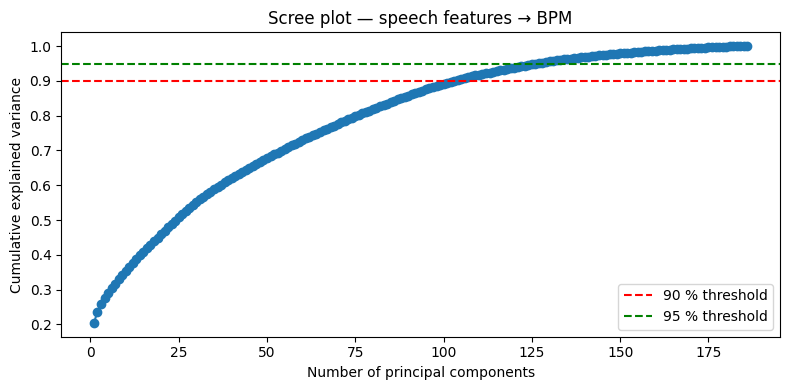

Components for 90 % variance: 103
Components for 95 % variance: 127


In [38]:
# Explained-variance scree plot 

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA().fit(X_proc)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker="o")
plt.axhline(0.90, color="r", linestyle="--", label="90 % threshold")
plt.axhline(0.95, color="g", linestyle="--", label="95 % threshold")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Scree plot — speech features → BPM")
plt.legend(); plt.tight_layout(); plt.show()

n90 = np.searchsorted(cumvar, 0.90) + 1
n95 = np.searchsorted(cumvar, 0.95) + 1
print(f"Components for 90 % variance: {n90}")
print(f"Components for 95 % variance: {n95}")

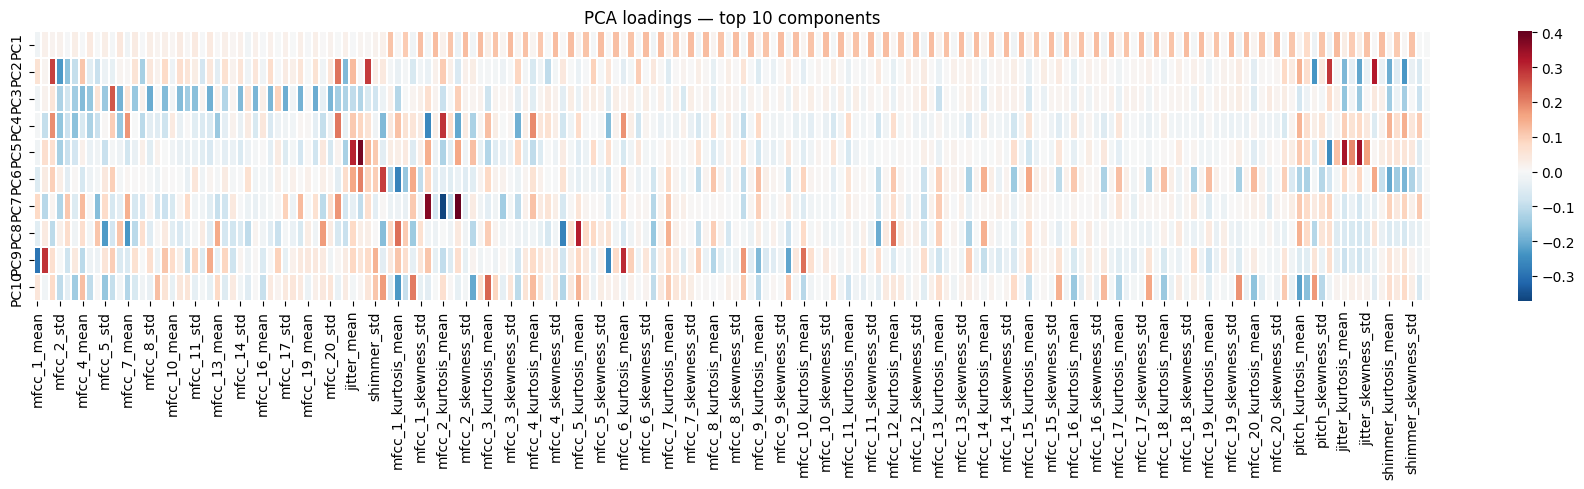

In [39]:
# Loadings heatmap (which features drive each PC)

loadings = pd.DataFrame(
    pca_full.components_[:10],            # first 10 PCs
    columns=agg.drop(columns=["file_name","bpm"]).columns,
    index=[f"PC{i}" for i in range(1, 11)]
)

import seaborn as sns
plt.figure(figsize=(18, 5))
sns.heatmap(loadings, cmap="RdBu_r", center=0, linewidths=0.3)
plt.title("PCA loadings — top 10 components")
plt.tight_layout(); plt.show()

# This reveals whether prosodic features (pitch_mean, jitter_std …) load separately from MFCC features — important for interpretability.

In [40]:
# PCA as a preprocessing step for BPM regression

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.decomposition import PCA

# Use speaker-independent folds (same pattern as Coding Pipeline.ipynb)
groups = agg["file_name"].str.extract(r"((En|Ta)\d+[MF]\d+)")[0]
cv = GroupKFold(n_splits=5)

n_total = X_proc.shape[1]
for n in [n90, n95, n_total]:     # compare compressed vs full
    pipe = Pipeline([
        ("pca",   PCA(n_components=n) if n < 46 else "passthrough"),
        ("model", Ridge()),
    ])
    scores = cross_val_score(pipe, X_proc, y, cv=cv, groups=groups,
                             scoring="neg_root_mean_squared_error")
    print(f"n={n:2d}  RMSE = {-scores.mean():.2f} ± {scores.std():.2f}")
    
# This directly answers: does PCA compression hurt or help BPM prediction?


n=103  RMSE = 0.00 ± 0.00
n=127  RMSE = 0.00 ± 0.00
n=186  RMSE = 0.00 ± 0.00


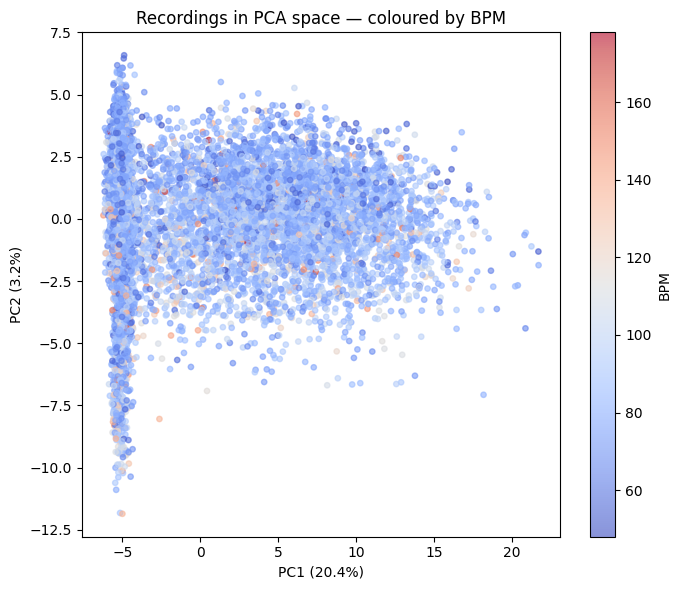

In [41]:
# 2-D BPM scatter
pca2 = PCA(n_components=2).fit_transform(X_proc)

plt.figure(figsize=(7, 6))
sc = plt.scatter(pca2[:, 0], pca2[:, 1], c=y, cmap="coolwarm",
                 alpha=0.6, s=15)
plt.colorbar(sc, label="BPM")
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
plt.title("Recordings in PCA space — coloured by BPM")
plt.tight_layout(); plt.show()

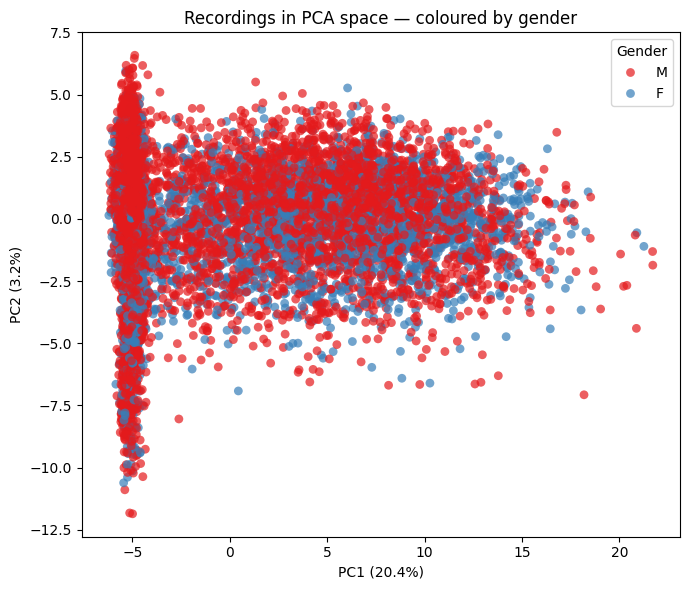

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meta = pd.read_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv", usecols=["file_name", "gender"])

pca_df = (
    pd.DataFrame(pca2, columns=["PC1", "PC2"])
    .assign(file_name=agg["file_name"])
    .merge(meta, on="file_name", how="left")
)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="gender",
    palette="Set1",
    alpha=0.7,
    s=40,
    edgecolor="none",
)
plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
plt.title("Recordings in PCA space — coloured by gender")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

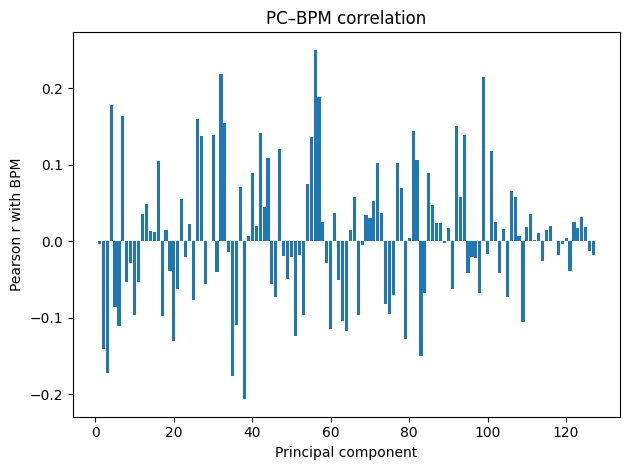

In [43]:
# Correlation of each PC with BPM

X_pca = PCA(n_components=n95).fit_transform(X_proc)

correlations = [np.corrcoef(X_pca[:, i], y)[0, 1] for i in range(n95)]
plt.bar(range(1, n95+1), correlations)
plt.xlabel("Principal component"); plt.ylabel("Pearson r with BPM")
plt.title("PC–BPM correlation"); plt.tight_layout(); plt.show()

# Identifies which PCs carry BPM-relevant variance — low-correlation PCs can be dropped without hurting prediction.

## Adding additional features to the analysis

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
meta = pd.read_csv("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/tesdhe_metadata.csv")


recording_features = (
    df.drop(columns=["frame_idx"])
      .groupby("file_name", as_index=False)
      .mean()
)

# Merge metadata
recording_features = recording_features.merge(
    meta[["file_name", "language", "response_type", "gender", "age_years"]],
    on="file_name",
    how="inner"
)

recording_features = pd.DataFrame(recording_features)


In [65]:
recording_features.head()

,file_name,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm,language,response_type,gender,age_years
0,En001M240401A083.ogg,0.8029,0.7004,0.4341,0.4148,0.4412,0.5235,0.5240,0.5863,0.5100,0.5259,0.6073,0.5681,0.4102,0.4421,0.6390,0.4404,0.5742,0.6867,0.4230,0.5573,0.4301,0.0162,0.1208,0.7300,0.0607,0.4382,0.4947,0.2158,0.2300,0.6540,0.0687,0.7377,0.5344,0.2982,0.6712,0.5402,0.1092,0.4350,0.4700,0.4774,0.1290,0.7634,0.2681,0.3454,0.7946,0.2414,0.4380,0.3861,0.4982,0.1727,0.6542,0.3126,0.3020,0.7823,0.2126,0.3130,0.7473,0.1855,0.4193,0.8499,0.0158,0.3870,0.8505,0.0000,0.5763,0.8694,0.1037,0.6018,0.9416,0.0445,0.5588,0.8555,0.1667,0.6601,0.7318,0.1410,0.6695,0.0329,0.8290,0.2017,0.8375,0.0520,0.5678,0.4625,0.0918,0.3925,0.9333,0.0005,0.0579,0.8407,0.0070,0.0951,83.0000,English,Answering,M,24
1,En001M240402A079.ogg,0.7750,0.4562,0.5032,0.4387,0.4975,0.5043,0.5729,0.6246,0.4961,0.5945,0.4765,0.5683,0.4823,0.4870,0.6101,0.5614,0.6043,0.6463,0.4620,0.5707,0.1750,0.0123,0.0565,0.8370,0.1885,0.4805,0.6979,0.0000,0.6405,0.6998,0.2566,0.7443,0.7849,0.1045,0.3204,0.5814,0.5406,0.2678,0.5539,0.3043,0.5338,0.7529,0.2597,0.2878,0.5080,0.5353,0.7951,0.2050,0.4469,0.2791,0.1162,0.6439,0.6104,0.8347,0.2187,0.8331,0.5721,0.3018,0.2431,0.7531,0.2508,0.2642,0.7752,0.2124,0.6744,0.4940,0.3941,1.0000,0.7058,0.1935,0.2568,0.8100,0.1675,0.6974,0.6849,0.4060,0.6360,0.5038,0.5473,0.8747,0.5730,0.5348,0.1740,0.2907,0.0126,0.6231,0.4036,0.3236,0.5410,0.5133,0.0383,0.2413,79.0000,English,Answering,M,24
2,En001M240403A076.ogg,0.6828,0.7819,0.4590,0.4813,0.5819,0.3871,0.4011,0.5630,0.4364,0.5888,0.5212,0.5308,0.5938,0.5467,0.5256,0.5394,0.6125,0.6405,0.6107,0.4512,0.4083,0.0212,0.1671,0.8844,0.0174,0.6266,0.6420,0.2687,0.3034,0.8663,0.1480,0.6801,0.6854,0.2167,0.5430,0.8335,0.0398,0.5002,0.6843,0.1539,0.7740,0.6937,0.1034,0.7564,0.5373,0.3720,0.4663,0.7492,0.0972,0.4422,0.6912,0.1814,0.4529,0.8589,0.0265,0.3999,0.8446,0.1012,0.7055,0.0000,0.9913,1.0000,0.7363,0.2307,0.7818,0.7989,0.1452,0.3954,0.6648,0.2373,0.6277,0.6880,0.1684,0.7929,0.8085,0.2414,0.3235,0.5077,0.5046,0.3649,0.6315,0.3541,0.0709,0.2345,0.0548,0.4284,0.9809,0.0123,0.0888,0.6740,0.1610,0.3473,76.0000,English,Answering,M,24
3,En001M240404A076.ogg,0.7003,0.3664,0.6247,0.5194,0.5488,0.4896,0.5018,0.6722,0.5143,0.4374,0.3979,0.6278,0.5368,0.4774,0.6432,0.5544,0.6208,0.5200,0.5240,0.5189,0.0816,0.0020,0.0120,0.8989,0.0427,0.5103,0.9390,0.0379,0.5794,0.6961,0.1231,0.5824,0.7143,0.1744,0.5287,0.7421,0.3623,0.3858,0.3576,0.2657,0.1936,0.6543,0.3177,0.3766,0.3889,0.2662,0.2901,0.7760,0.0835,0.5835,0.6256,0.2710,0.4075,0.4395,0.5762,0.6624,0.6134,0.2149,0.7408,0.4878,0.4905,0.6023,0.8514,0.2015,0.7508,0.1950,0.5965,0.4129,0.7922,0.1694,0.2708,0.9534,0.0656,0.5685,0.5936,0.4785,0.5813,0.3

### Feature–BPM association plot
Spearman is more robust than Pearson here

This shows which extracted features are most related to BPM.

For your poster, the useful interpretation is:

	•	features with larger absolute correlation may be more promising predictors

	•	if correlations are small, that still supports the need for nonlinear models like CNN/XGBoost


OHE columns created: ['lang_English', 'lang_Tamil', 'gender_F', 'gender_M', 'response_AfterVideo', 'response_Answering', 'response_Reading']


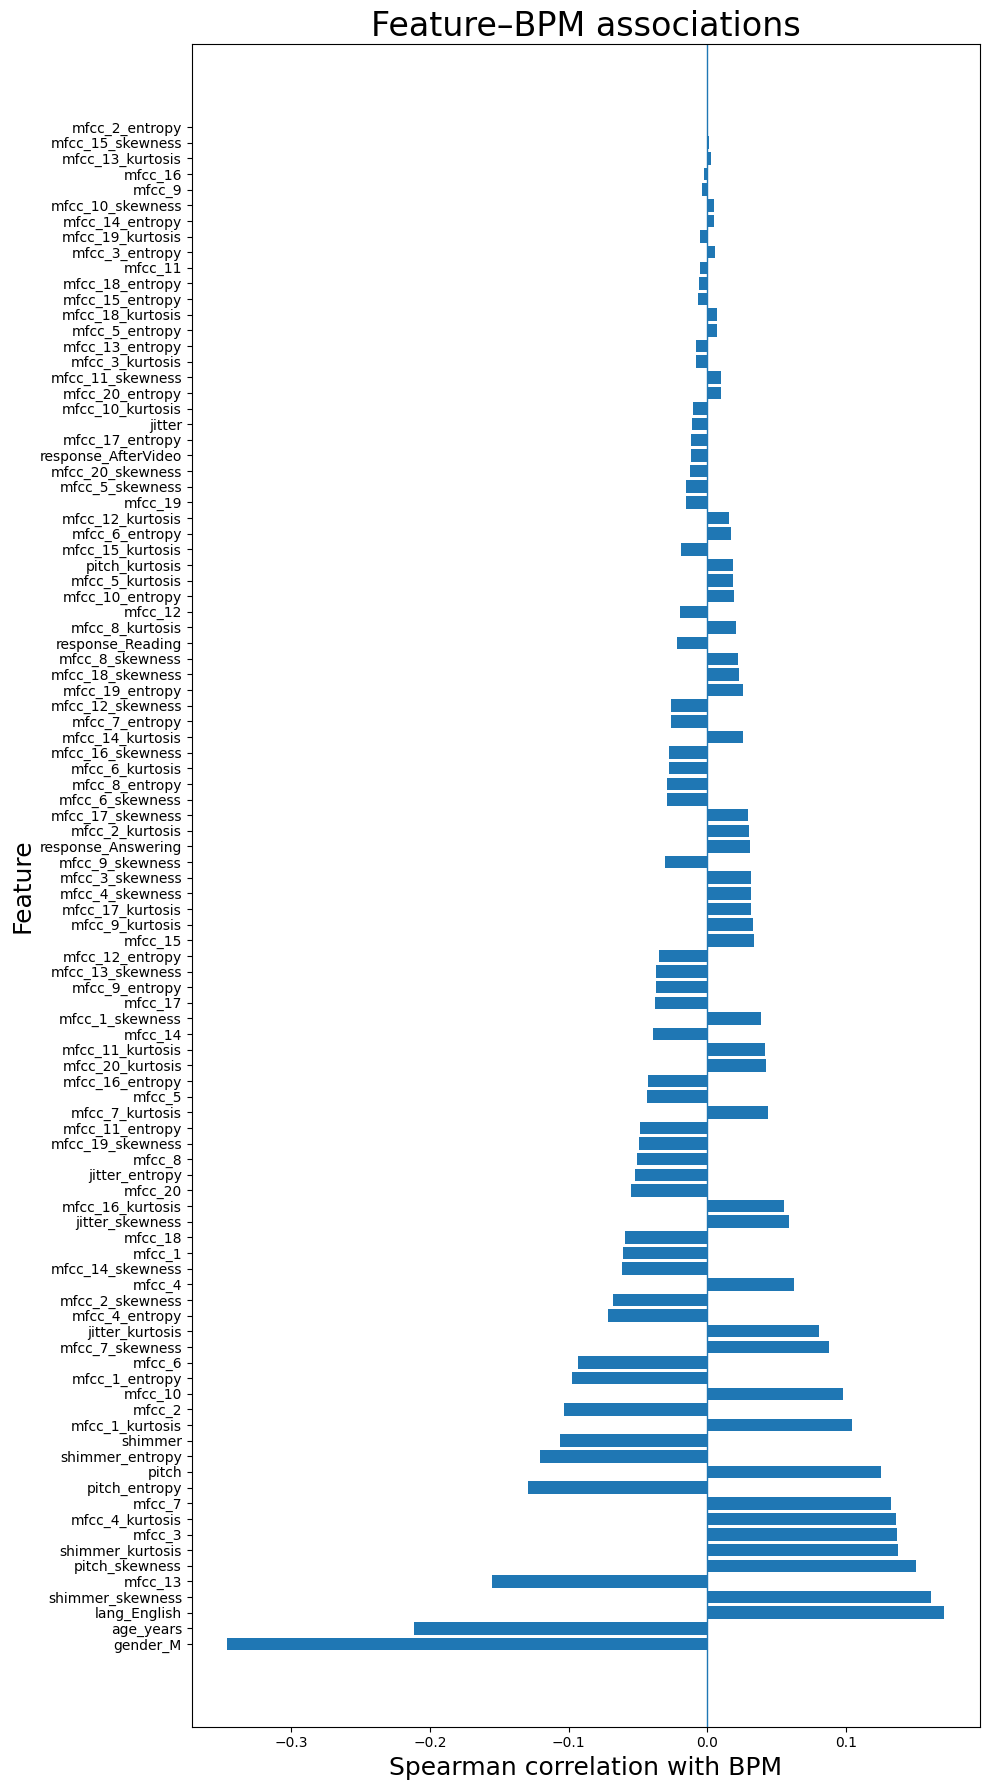

Top feature–BPM associations:
             feature  spearman_rho
94          gender_M       -0.3458
92         age_years       -0.2113
93      lang_English        0.1707
91  shimmer_skewness        0.1612
12           mfcc_13       -0.1553
85    pitch_skewness        0.1505
90  shimmer_kurtosis        0.1373
2             mfcc_3        0.1370
33   mfcc_4_kurtosis        0.1358
6             mfcc_7        0.1325


In [69]:
import pandas as pd

# --- One-Hot Encode categorical metadata ---
# Language: binary (English/Tamil) -> one column is enough
# Gender:   binary (M/F)           -> one column is enough
# Response: 3 levels (Answering/Reading/Video) -> all three kept for interpretability
recording_features_ohe = pd.get_dummies(
    recording_features,
    columns=["language", "gender", "response_type"],
    prefix=["lang", "gender", "response"],
    drop_first=False,   # keep all levels; we drop redundant ones manually below
    dtype=float,        # so pandas' boolean dummies become 0.0/1.0 for .corr()
)

# Quick sanity check so future runs won't silently break if category labels change
print("OHE columns created:", [c for c in recording_features_ohe.columns
                               if c.startswith(("lang_", "gender_", "response_"))])

# Binary features (language, gender): drop one side of each redundant pair.
# The remaining column acts as an indicator; its sign shows direction.
# Kept: lang_English (positive corr = English associated with higher BPM)
#       gender_M     (positive corr = males associated with higher BPM)
recording_features_ohe = recording_features_ohe.drop(columns=["lang_Tamil", "gender_F"])

# Response type: keep all three columns so each bar in the plot shows
# "this response type vs. the other two combined".

# --- Feature-BPM correlation plot (unchanged logic below) ---
numeric_cols = recording_features_ohe.select_dtypes(include="number").columns.drop("bpm")

corrs = {}
for col in numeric_cols:
    valid = recording_features_ohe[[col, "bpm"]].dropna()
    corrs[col] = valid[col].corr(valid["bpm"], method="spearman")

corr_df = (
    pd.DataFrame({"feature": list(corrs.keys()), "spearman_rho": list(corrs.values())})
    .sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False)
)

plt.figure(figsize=(10, 18))
plt.barh(corr_df["feature"], corr_df["spearman_rho"])
plt.axvline(0, linewidth=1)
plt.ylabel("Feature", fontsize=18)
plt.xlabel("Spearman correlation with BPM", fontsize=18)
plt.title("Feature–BPM associations", fontsize=24)
plt.tight_layout()
plt.show()

print("Top feature–BPM associations:")
print(corr_df.head(10))

### Mean MFCC profiles by response type

This shows whether the cepstral shape differs by speaking condition.

That is relevant because response condition may be a confound or useful source of variation.


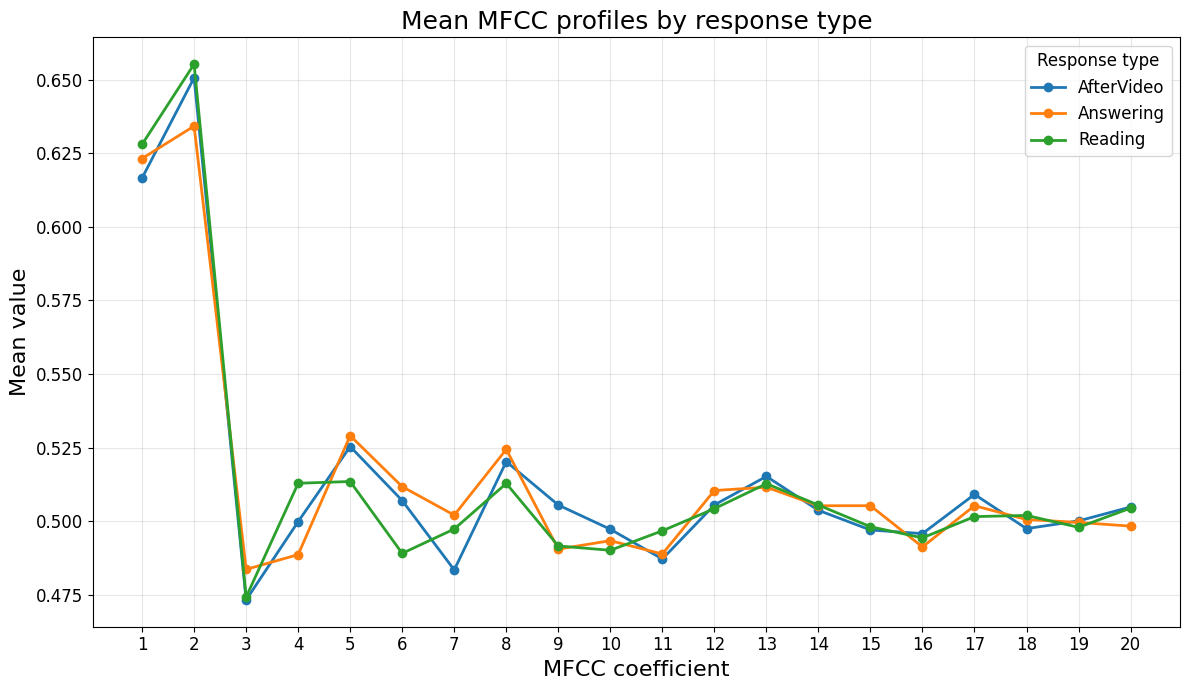

In [70]:
response_groups = (
    recording_features
    .groupby("response_type")[mfcc_cols]
    .mean()
)

plt.figure(figsize=(12, 7))
for group in response_groups.index:
    plt.plot(
        range(1, 21),
        response_groups.loc[group].values,
        marker="o",
        linewidth=2,
        label=group
    )

plt.xlabel("MFCC coefficient", fontsize=16)
plt.ylabel("Mean value", fontsize=16)
plt.title("Mean MFCC profiles by response type", fontsize=18)
plt.xticks(range(1, 21), fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, title="Response type", title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3. Mean MFCC profiles by BPM group

This is probably the most directly useful plot for your project.

It shows whether recordings with lower vs higher BPM have different average MFCC patterns.


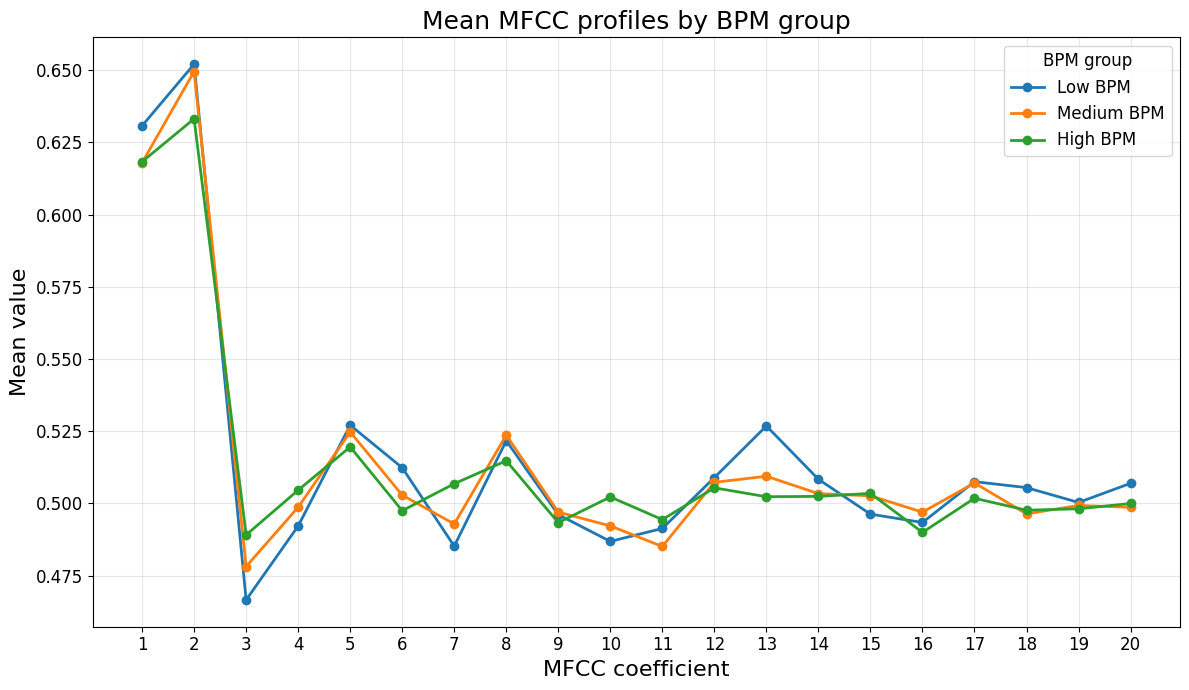


BPM group cutoffs:
0.0000    48.0000
0.3333    80.0000
0.6667    93.0000
1.0000   178.0000
Name: bpm, dtype: float64


In [71]:
# Use tertiles: low / medium / high BPM

recording_features["bpm_group"] = pd.qcut(
    recording_features["bpm"],
    q=3,
    labels=["Low BPM", "Medium BPM", "High BPM"]
)

bpm_groups = (
    recording_features
    .groupby("bpm_group")[mfcc_cols]
    .mean()
)

plt.figure(figsize=(12, 7))
for group in bpm_groups.index:
    plt.plot(
        range(1, 21),
        bpm_groups.loc[group].values,
        marker="o",
        linewidth=2,
        label=group
    )

plt.xlabel("MFCC coefficient", fontsize=16)
plt.ylabel("Mean value", fontsize=16)
plt.title("Mean MFCC profiles by BPM group", fontsize=18)
plt.xticks(range(1, 21), fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, title="BPM group", title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: print BPM group cutoffs
# ----------------------------
bpm_cutoffs = recording_features["bpm"].quantile([0, 1/3, 2/3, 1]).round(2)
print("\nBPM group cutoffs:")
print(bpm_cutoffs)

## Trial dataset 
For GPU training test, 10 first entries

In [72]:
import pandas as pd

In [73]:
df = pd.read_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/stage_4_normalised.parquet")
df_sample = df.sample(10, random_state=42)

df_sample.to_parquet("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/data/dataset_sample.parquet", index=False)


In [74]:
df_sample.head()

,file_name,frame_idx,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20,pitch,jitter,shimmer,mfcc_1_entropy,mfcc_1_kurtosis,mfcc_1_skewness,mfcc_2_entropy,mfcc_2_kurtosis,mfcc_2_skewness,mfcc_3_entropy,mfcc_3_kurtosis,mfcc_3_skewness,mfcc_4_entropy,mfcc_4_kurtosis,mfcc_4_skewness,mfcc_5_entropy,mfcc_5_kurtosis,mfcc_5_skewness,mfcc_6_entropy,mfcc_6_kurtosis,mfcc_6_skewness,mfcc_7_entropy,mfcc_7_kurtosis,mfcc_7_skewness,mfcc_8_entropy,mfcc_8_kurtosis,mfcc_8_skewness,mfcc_9_entropy,mfcc_9_kurtosis,mfcc_9_skewness,mfcc_10_entropy,mfcc_10_kurtosis,mfcc_10_skewness,mfcc_11_entropy,mfcc_11_kurtosis,mfcc_11_skewness,mfcc_12_entropy,mfcc_12_kurtosis,mfcc_12_skewness,mfcc_13_entropy,mfcc_13_kurtosis,mfcc_13_skewness,mfcc_14_entropy,mfcc_14_kurtosis,mfcc_14_skewness,mfcc_15_entropy,mfcc_15_kurtosis,mfcc_15_skewness,mfcc_16_entropy,mfcc_16_kurtosis,mfcc_16_skewness,mfcc_17_entropy,mfcc_17_kurtosis,mfcc_17_skewness,mfcc_18_entropy,mfcc_18_kurtosis,mfcc_18_skewness,mfcc_19_entropy,mfcc_19_kurtosis,mfcc_19_skewness,mfcc_20_entropy,mfcc_20_kurtosis,mfcc_20_skewness,pitch_entropy,pitch_kurtosis,pitch_skewness,jitter_entropy,jitter_kurtosis,jitter_skewness,shimmer_entropy,shimmer_kurtosis,shimmer_skewness,bpm
48678,En007M230120R085.ogg,28,0.9130,0.5662,0.6984,0.6580,0.5302,0.4163,0.3652,0.5709,0.5257,0.2110,0.4063,0.3989,0.4654,0.4867,0.6391,0.3237,0.7212,0.7118,0.6785,0.6037,0.6290,0.0000,0.0642,0.7689,0.1470,0.6202,0.6002,0.2026,0.4387,0.7500,0.2367,0.4379,0.8325,0.1996,0.6465,0.5535,0.4756,0.3492,0.7872,0.1160,0.3787,0.7253,0.2607,0.5362,0.7309,0.2569,0.2357,0.7892,0.2687,0.4927,0.8089,0.1878,0.4046,0.6072,0.2480,0.6810,0.6686,0.3145,0.4144,0.7202,0.1730,0.3239,0.5810,0.2937,0.3191,0.6901,0.2490,0.4473,0.7618,0.1948,0.7643,0.5607,0.2786,0.5559,0.7650,0.1467,0.4950,0.9361,0.2073,0.4901,0.8652,0.2435,0.5668,0.5862,0.0044,0.6349,0.3430,0.5000,0.5945,0.5244,0.3844,0.5517,85
567753,En103M191123R073.ogg,211,0.5419,0.6109,0.2666,0.3540,0.5239,0.6622,0.5075,0.5061,0.3913,0.5743,0.4621,0.7594,0.7028,0.5808,0.6847,0.4666,0.4882,0.5010,0.4680,0.2715,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.5908,0.3669,0.5135,0.6345,0.4611,0.7449,0.0000,0.9931,0.5883,0.6783,0.3511,0.6185,0.2171,0.7343,0.2878,0.0000,0.6060,0.0230,0.1977,0.9047,1.0000,0.5410,0.3048,0.4501,0.7307,0.3502,0.5640,0.0000,1.0000,1.0000,0.5647,0.3759,0.3978,0.7485,0.3755,0.5661,0.8969,0.2046,0.4237,0.5913,0.3042,0.5495,0.4389,0.4784,0.0366,0.5051,0.2926,0.3148,0.7602,0.1977,0.5468,0.6583,0.2225,0.5142,0.5785,0.4091,0.5633,0.0000,0.2078,0.4196,0.0000,0.0272,0.0000,0.0000,0.0443,0.0177,73
362097,En072F400162V094.ogg,75,0.7042,0.7201,0.4094,0.2525,0.2244,0.7195,0.5227,0.6893,0.4858,0.4405,0.6515,0.5307,0.5542,0.4689,0.4464,0.4880,0.6843,0.6795,0.3999,0.4427,0.6686,0.0042,0.1054,0.8940,0.1907,0.4639,0.8199,0.1109,0.6580,0.8524,0.1686,0.5552,0.7456,0.2061,0.5940,0.7842,0.3229,0.3326,0.3452,0.5712,0.0889,0.6665,0.2961,0.4337,0.7279,0.2218,0.7212,0.4685,0.4275,0.4932,0.7038,0.1209,0.3066,0.6308,0.2471,0.4019,0.5928,0.3218,0.6402,0.3369,0.6008,0.8403,0.2170,0.5388,0.5114,0.6663,0.2518,0.6719,0.8786,0.1456,0.3342,0.8392,0.1706,0.4126,0.1586,0.9488,0.0099,0.8581,0.0974,0.4684,0.6689,0.3418,0.4765,0.3564,0.0703,0.6232,0.6662,0.1309,0.2794,0.9266,0.0616,0.1896,94
966384,Ta069F350841R086.ogg,48,0.8473,0.6563,0.3382,0.4139,0.2793,0.4971,0.5823,0.5311,0.6686,0.4515,0.2948,0.4616,0.5380,0.4884,0.5178,0.4562,0.3978,0.4070,0.4239,0.5218,0.7869,0.0297,0.2999,0.8400,0.2346,0.3345,0.5637,0.3162,0.4295,0.5721,0.4581,0.2936,0.3725,1.0000,0.0072,0.9089,0.1395,0.6117,0.4648,0.4101,0.4959,0.5717,0.3535,0.2463,0.3503,0.4295,0.6649,0.6052,0.2775,0.5651,0.6309,0.3323,0.7545,0.8899,0.1506,0.6067,0.7113,0.1485,0.5152,0.6386,0.3019,0.3446,0.8029,0.1584,0.6974,0.6919,0.2434,0.2902,0.6677,0.1771,0.4721,0.7804,0.0985,0.4072,0.8181,0.1750,0.4679,0.8563,0.1208,0.5308,0.5932,0.2568,0.5939,0.3512,0.1677,0.4377,0.5879,0.3010,0.3836,0

### Questions and follow-up:

